# **Projet 7 : Implémentez un modèle de scoring**

**Introduction du projet** : 
Vous êtes Data Scientist au sein d'une société financière, nommée "Prêt à dépenser", qui propose des crédits à la consommation pour des personnes ayant peu ou pas du tout d'historique de prêt. L’entreprise souhaite mettre en œuvre un outil de “scoring crédit” pour calculer la probabilité qu’un client rembourse son crédit, puis classifie la demande en crédit accordé ou refusé. Elle souhaite donc développer un algorithme de classification en s’appuyant sur des sources de données variées (données comportementales, données provenant d'autres institutions financières, etc.)

**Mission** :
- Construire un modèle de scoring qui donnera une prédiction sur la probabilité de faillite d'un client de façon automatique.

- Analyser les features qui contribuent le plus au modèle, d’une manière générale (feature importance globale) et au niveau d’un client (feature importance locale), afin, dans un soucis de transparence, de permettre à un chargé d’études de mieux comprendre le score attribué par le modèle.

- Mettre en production le modèle de scoring de prédiction à l’aide d’une API et réaliser une interface de test de cette API.

- Mettre en œuvre une approche globale MLOps de bout en bout, du tracking des expérimentations à l’analyse en production du data drift.

### 📚 **Sommaire**

1. **Description des données**

2. **Analyse exploratoire des données**

    - 2.1. application_train
    - 2.2. application_test
    - 2.3. Distribution de la colonne 'TARGET'
    - 2.4. Type des colonnes

3. **Préparation des données**

    - 3.1. One hot encoding des colonnes catégorielles
    - 3.2. Feature engineering
    - 3.3. Corrélations
    - 3.4. Enregistrement des données
    - 3.5. Métriques d'évaluation / Score métier
    - 3.6. Déséquilibre des classes


### **0. Imports, config et helpers généraux** 

In [108]:
import os, gc, json, warnings, time, re
from datetime import datetime
from collections import defaultdict
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import missingno as msno
import seaborn as sns

# ML de base
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_validate
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score, make_scorer
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, KFold
from scipy.stats import randint, uniform
from sklearn.base import clone

from lightgbm import LGBMClassifier, early_stopping, log_evaluation

import joblib

# XGBoost
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except Exception:
    HAS_XGB = False

# Imbalance
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Suivi expé
import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

# Explicabilité
import shap

# Data drift (Evidently)
try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset
    from evidently.metrics import DatasetDriftMetric, DataDriftTable
    from evidently import ColumnMapping
    HAS_EVIDENTLY = True
except Exception:
    HAS_EVIDENTLY = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
DATA_DIR = "Data"

In [92]:
# === Helpers ===
def one_hot_encoder(df: pd.DataFrame, nan_as_category: bool = False):
    """One-hot encode des colonnes 'object' (dummy_na contrôlé)."""
    original_columns = list(df.columns)
    categorical_columns = [col for col in df.columns if df[col].dtype == 'object']
    df = pd.get_dummies(df, columns=categorical_columns, dummy_na=nan_as_category)
    new_columns = [c for c in df.columns if c not in original_columns]
    return df, new_columns

def _cleanup_inf_to_nan(X):
    """Remplace inf/-inf par NaN et force float64 pour l'imputation."""
    if isinstance(X, pd.DataFrame):
        X = X.replace([np.inf, -np.inf], np.nan)
        return X.astype(np.float64)
    X = X.astype(np.float64, copy=True)
    X[~np.isfinite(X)] = np.nan
    return X

import numpy as np
from sklearn.metrics import confusion_matrix

def compute_business_score(
    y_true,
    y_pred,
    tp_coeff: float = 1.0,
    fp_coeff: float = -1.0,
    fn_coeff: float = -10.0,
    tn_coeff: float = 0.0,
    normalize: bool = False,
    return_breakdown: bool = False,
    threshold: float | None = None,
):
    """
    Calcule le gain métier:
      TP:+tp_coeff | FP:fp_coeff | FN:fn_coeff | TN:tn_coeff (par défaut 0)

    - y_pred peut être binaire (0/1) ou probabilités si threshold est fourni.
    - normalize=True renvoie un gain moyen par observation.
    - return_breakdown=True renvoie aussi le détail TP/FP/FN/TN.
    """
    y_true = np.asarray(y_true)

    y_pred = np.asarray(y_pred)
    # Si des proba sont passées et qu'on fournit un threshold, on binarise
    if threshold is not None:
        y_pred = (y_pred >= threshold).astype(int)

    # Vérifications de base
    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError("y_true et y_pred doivent avoir la même longueur.")
    # S'assurer que y_pred est bien binaire
    uniques = np.unique(y_pred)
    if not np.all(np.isin(uniques, [0, 1])):
        raise ValueError(
            "y_pred doit être binaire (0/1). "
            "Si tu fournis des probabilités, passe un threshold=..."
        )

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    gain = tp_coeff * tp + fp_coeff * fp + fn_coeff * fn + tn_coeff * tn
    if normalize:
        gain = gain / len(y_true)

    if return_breakdown:
        breakdown = {"TP": int(tp), "FP": int(fp), "FN": int(fn), "TN": int(tn)}
        return gain, breakdown
    return gain


def best_threshold_for_business(y_true, y_proba,
                               tp_coeff=1.0, fp_coeff=-1.0, fn_coeff=-10.0,
                               n_points: int = 201):
    """Cherche un seuil approx. (par quantiles) maximisant le gain métier."""
    qs = np.linspace(0, 1, n_points)
    thr_candidates = np.unique(np.quantile(y_proba, qs))
    best_gain, best_thr = -np.inf, 0.5
    for thr in thr_candidates:
        y_pred = (y_proba >= thr).astype(int)
        gain = compute_business_score(y_true, y_pred, tp_coeff, fp_coeff, fn_coeff)
        if gain > best_gain:
            best_gain, best_thr = gain, thr
    return float(best_thr), float(best_gain)

def missing_values_table(df):
    mis_val = df.isnull().sum()
    mis_val_percent = 100 * df.isnull().sum() / len(df)
    mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)
    mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})
    mis_val_table_ren_columns = mis_val_table_ren_columns[
        mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)
    print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"      
        "There are " + str(mis_val_table_ren_columns.shape[0]) +
          " columns that have missing values.")
    return mis_val_table_ren_columns

def sanitize_colnames_for_lgbm(X):
    """
    Remplace tout caractère non [0-9A-Za-z_] par '_' et garantit l'unicité.
    Si la première lettre est un chiffre → préfixe 'f_'.
    Ne touche rien si X n'est pas un DataFrame.
    """
    if not isinstance(X, pd.DataFrame):
        return X
    
    cols = list(map(str, X.columns))
    cleaned = []
    seen = set()
    for c in cols:
        nc = re.sub(r'[^0-9A-Za-z_]+', '_', c).strip('_')
        if not nc:
            nc = "f"
        if nc[0].isdigit():
            nc = f"f_{nc}"
        base = nc
        i = 1
        while nc in seen:
            nc = f"{base}_{i}"
            i += 1
        seen.add(nc)
        cleaned.append(nc)
    X = X.copy()
    X.columns = cleaned
    return X

def _is_sampler(step_obj):
    """Détecte un sampler imblearn (possède fit_resample)."""
    return hasattr(step_obj, "fit_resample")

def _is_transformer(step_obj):
    """A un transform utilisable en inference."""
    return hasattr(step_obj, "transform")

def _fit_prepro_steps(pre_steps, X_tr, y_tr):
    """
    Fit les étapes de préprocessing (dont samplers).
    - Transforme X_tr au fur et à mesure
    - Applique fit_resample pour les samplers
    - Retourne X_tr_res, y_tr_res, et la liste des étapes FITTÉES (dans l’ordre)
    """
    X_cur, y_cur = X_tr, y_tr
    fitted = []

    for name, step in pre_steps:
        step_f = clone(step)

        if _is_sampler(step_f):
            # Sampler: on resample en TRAIN
            X_cur, y_cur = step_f.fit_resample(X_cur, y_cur)
            fitted.append((name, step_f))
        else:
            # Transformer classique
            # Si le step supporte fit_transform, on l'utilise
            if hasattr(step_f, "fit_transform"):
                X_cur = step_f.fit_transform(X_cur, y_cur)
            else:
                step_f.fit(X_cur, y_cur)
                X_cur = step_f.transform(X_cur)
            fitted.append((name, step_f))

    return X_cur, y_cur, fitted

def _apply_prepro_steps_inference(fitted_steps, X_va):
    """
    Applique en VALIDATION uniquement les étapes "transformables".
    - Ignore les samplers (pas de resampling sur la validation)
    - Respecte l’ordre des étapes
    """
    X_cur = X_va
    for name, step_f in fitted_steps:
        if _is_sampler(step_f):
            # rien à faire en validation
            continue
        # Transformer
        X_cur = step_f.transform(X_cur)
    return X_cur    

def sanitize_feature_names(df: pd.DataFrame):
    """LightGBM n'aime pas les caractères spéciaux → on nettoie les noms de colonnes et on renvoie le mapping."""
    out = df.copy()
    mapping = {}
    used = set()
    for c in out.columns.astype(str):
        nc = re.sub(r'[^0-9A-Za-z_]+', '_', c).strip('_')
        if nc and nc[0].isdigit(): nc = f"f_{nc}"
        if not nc: nc = "f_unnamed"
        # unicité
        base = nc; k=1
        while nc in used:
            k += 1
            nc = f"{base}_{k}"
        used.add(nc)
        mapping[c] = nc
    out = out.rename(columns=mapping)
    return out, mapping

### **1. Description des données** 

Pour la description et l'analyse exploratoire des données nous nous baserons sur le kernel Kaggle suivant : [Start Here: A Gentle Introduction](https://www.kaggle.com/code/willkoehrsen/start-here-a-gentle-introduction/notebook)

Chaque fichier représente une table reliée par un ou plusieurs identifiants :

- application_train / application_test : Données principales des clients actuels, utilisées pour prédire le risque de défaut.
  - Table principale : 1 ligne = 1 prêt en cours
  - Identifiant : `SK_ID_CURR`
  - Colonne `TARGET` : 0 = prêt remboursé / 1 = non remboursé

- bureau : Historique des prêts des clients dans d’autres banques.
  - Chaque ligne = un ancien crédit.
  - Identifiant : `SK_ID_BUREAU`
  - Clé de lien : `SK_ID_CURR`

- bureau_balance : Suivi mois par mois de l’évolution des anciens crédits détenus dans d’autres institutions.
  - Chaque ligne = un mois de suivi d’un ancien crédit.
  - Clé de lien : `SK_ID_BUREAU`

- previous_application : Historique des anciennes demandes de prêt internes à Home Credit.
  - Chaque ligne = une ancienne demande de prêt.
  - Identifiant : `SK_ID_PREV`
  - Clé de lien : `SK_ID_CURR`

- POS_CASH_BALANCE : Historique mensuel des anciens crédits à la consommation chez Home Credit.
  - Chaque ligne = un mois d’un prêt POS ou cash.
  - Clés de lien : `SK_ID_PREV` → `previous_application`

- credit_card_balance : Historique mensuel des balances de cartes de crédit détenues chez Home Credit.
  - Chaque ligne = un mois d’un relevé de carte de crédit.
  - Clés de lien : `SK_ID_PREV` → `previous_application`

- installments_payment : Historique détaillé des paiements effectués ou manqués des anciens prêts Home Credit.
  - Chaque ligne = un paiement réalisé ou manqué.
  - Clés de lien : `SK_ID_PREV` → `previous_application`


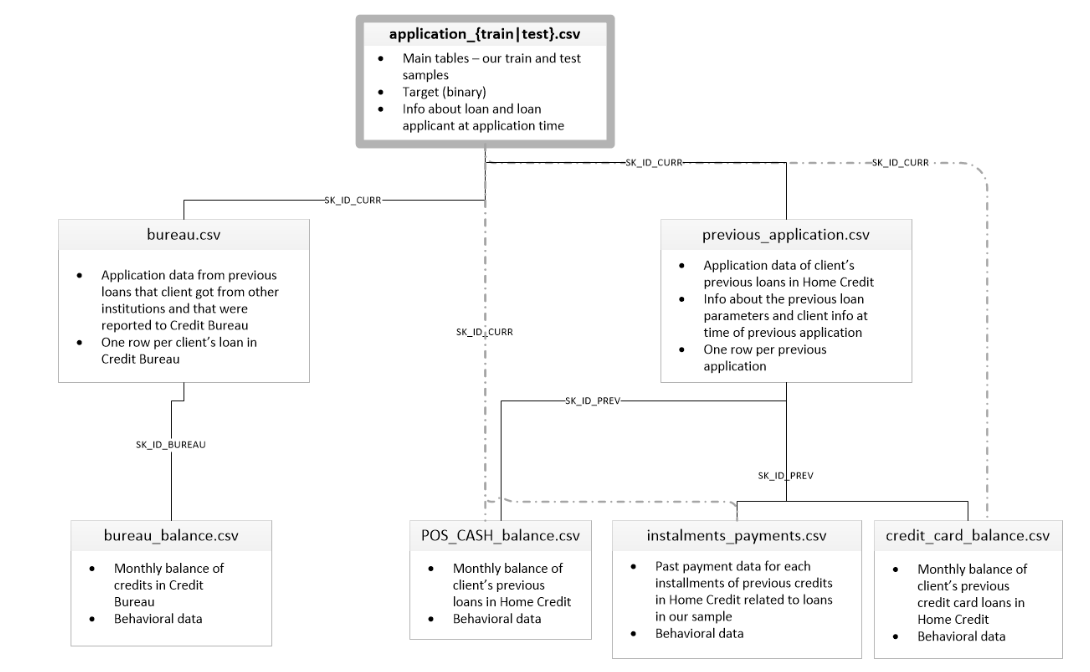

### **2. Analyse exploratoire et préparation des données** 

In [39]:
print(os.listdir("Data/"))

['application_test.csv', 'application_train.csv', 'bureau.csv', 'bureau_balance.csv', 'credit_card_balance.csv', 'df_merged.csv', 'HomeCredit_columns_description.csv', 'installments_payments.csv', 'POS_CASH_balance.csv', 'previous_application.csv', 'sample_submission.csv']


#### **2.1. application_train – chargement + premières vérifications**

In [40]:
app_train = pd.read_csv(os.path.join(DATA_DIR, "application_train.csv"))
print('Training data shape: ', app_train.shape)
app_train.head()

Training data shape:  (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

Les données d'entrainement contiennent 307 511 observations (chacune étant un prêt distinct) et 122 colonnes (variables), y compris la colonne `TARGET` (l'étiquette que nous voulons prédire).

In [41]:
print("Le nombre de doublons dans les données d'entrainement est de : ", 
      app_train[app_train.duplicated()].shape[0])

Le nombre de doublons dans les données d'entrainement est de :  0


In [42]:
# Afficher le taux de remplissage
total_missing_values = app_train.isnull().sum().sum()
taux_de_remplissage = 1 - (total_missing_values / app_train.size)
taux_de_remplissage = taux_de_remplissage*100
print(f"Taux de remplissage : {taux_de_remplissage:.2f}%")

Taux de remplissage : 75.60%


In [43]:
# Statistiques des valeurs manquantes
missing_values = missing_values_table(app_train)
missing_values.head(20)

Your selected dataframe has 122 columns.
There are 67 columns that have missing values.


,Missing Values,% of Total Values
COMMONAREA_MEDI,214865,69.9
COMMONAREA_AVG,214865,69.9
COMMONAREA_MODE,214865,69.9
NONLIVINGAPARTMENTS_MEDI,213514,69.4
NONLIVINGAPARTMENTS_MODE,213514,69.4
NONLIVINGAPARTMENTS_AVG,213514,69.4
FONDKAPREMONT_MODE,210295,68.4
LIVINGAPARTMENTS_MODE,210199,68.4
LIVINGAPARTMENTS_MEDI,210199,68.4
LIVINGAPARTMENTS_AVG,210199,68.4


On remarque que 67 colonnes possèdent des valeurs manquantes (avec un taux de remplissage total de 75% environ), nous devrons donc compléter ces valeurs manquantes. Nous pourrons utiliser des modèles tels que LGBM, capables de gérer les valeurs manquantes sans recourir à l'imputation. Une autre option consisterait à supprimer les colonnes présentant un pourcentage élevé de valeurs manquantes, bien qu'il soit impossible de savoir à l'avance si ces colonnes seront utiles à notre modèle. Par conséquent, nous conserverons toutes les colonnes pour l'instant.

#### **2.2. application_test – chargement + premières vérifications**

In [44]:
app_test = pd.read_csv(os.path.join(DATA_DIR, "application_test.csv"))
print('Testing data shape: ', app_test.shape)
app_test.head()

Testing data shape:  (48744, 121)


,SK_ID_CURR,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100001,Cash loans,F,N,Y,0,135000.0,568800.0,20560.5,450000.0,Unaccompanied,Working,Higher education,Married,House / apartment,0.018850,-19241,-2329,-5170.0,-812,NaN,1,1,0,1,0,1,NaN,2.0,2,2,TUESDAY,18,0,0,0,0,0,0,Kindergarten,0.752614,0.789654,0.159520,0.0660,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0505,NaN,NaN,0.0672,0.0612,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0526,NaN,NaN,0.0666,0.0590,0.9732,NaN,NaN,NaN,0.1379,0.125,NaN,NaN,NaN,0.0514,NaN,NaN,NaN,block of flats,0.0392,"Stone, brick",No,0.0,0.0,0.0,0.0,-1740.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
1,100005,Cash loans,M,N,Y,0,99000.0,222768.0,17370.0,180000.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,0.035792,-18064,-4469,-9118.0,-1623,NaN,1,1,0,1,0,0,Low-skill Laborers,2.0,2,2,FRIDAY,9,0,0,0,0,0,0,Self-employed,0.564990,0.291656,0.432962,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,3.0
2,100013,Cash loans,M,Y,Y,0,202500.0,663264.0,69777.0,630000.0,NaN,Working,Higher education,Married,House / apartment,0.019101,-20038,-4458,-2175.0,-3503,5.0,1,1,0,1,0,0,Drivers,2.0,2,2,MONDAY,14,0,0,0,0,0,0,Transport: type 3,NaN,0.699787,0.610991,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,-856.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,1.0,4.0
3,100028,Cash loans,F,N,Y,2,315000.0,1575000.0,49018.5,1575000.0,Unaccompanied,Working,Secondary / secondary special,Married

Les données d'entrainement contiennent 48 744 observations (chacune étant un prêt distinct) et 121 colonnes (variables).

In [45]:
print("Le nombre de doublons dans les données de test est de : ", 
      app_test[app_test.duplicated()].shape[0])

Le nombre de doublons dans les données de test est de :  0


In [46]:
# Afficher le taux de remplissage
total_missing_values = app_test.isnull().sum().sum()
taux_de_remplissage = 1 - (total_missing_values / app_test.size)
taux_de_remplissage = taux_de_remplissage*100
print(f"Taux de remplissage : {taux_de_remplissage:.2f}%")

Taux de remplissage : 76.19%


#### **2.3. Distribution de la colonne `TARGET`**

In [47]:
app_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

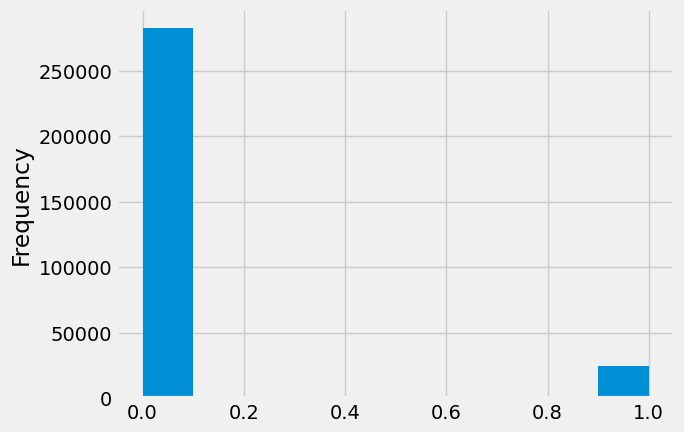

In [48]:
app_train['TARGET'].astype(int).plot.hist()

On remarque que les classes sont déséquilibrées. Les prêts remboursés à temps sont bien plus nombreux que ceux non remboursés. Nous devrons donc pondérer les classes selon leur représentation dans les données afin de refléter ce déséquilibre.

#### **2.4. Typage des colonnes et cardinalité des variables catégorielles**

In [49]:
# Réparition des colonnes pour chaque type
app_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

In [50]:
# Nombre de classes uniques dans chaque colonne d'objet
app_train.select_dtypes('object').apply(pd.Series.nunique, axis = 0)

NAME_CONTRACT_TYPE             2
CODE_GENDER                    3
FLAG_OWN_CAR                   2
FLAG_OWN_REALTY                2
NAME_TYPE_SUITE                7
NAME_INCOME_TYPE               8
NAME_EDUCATION_TYPE            5
NAME_FAMILY_STATUS             6
NAME_HOUSING_TYPE              6
OCCUPATION_TYPE               18
WEEKDAY_APPR_PROCESS_START     7
ORGANIZATION_TYPE             58
FONDKAPREMONT_MODE             4
HOUSETYPE_MODE                 3
WALLSMATERIAL_MODE             7
EMERGENCYSTATE_MODE            2
dtype: int64

La plupart des variables catégorielles ont un nombre relativement faible d'entrées uniques. Il nous faudra trouver un moyen de les gérer.

#### **2.5. Détection et marquage des anomalies (DAYS_BIRTH / DAYS_EMPLOYED)**

Un problème que nous devons toujours surveiller lors de l'analyse des données de l'EDA est la présence d'anomalies dans les données. Celles-ci peuvent être dues à des erreurs de saisie, à des erreurs d'équipement de mesure, ou à des mesures valides mais extrêmes. Une façon de justifier quantitativement les anomalies consiste à examiner les statistiques d'une colonne à l'aide de la méthode describe. Les nombres de la colonne DAYS_BIRTH sont négatifs car ils sont enregistrés par rapport à la demande de prêt en cours.

- `DAYS_BIRTH`

Pour afficher ces statistiques en années, nous pouvons multiplier par -1 et diviser par le nombre de jours dans une année.

In [51]:
(app_train['DAYS_BIRTH'] / -365).describe()

count    307511.000000
mean         43.936973
std          11.956133
min          20.517808
25%          34.008219
50%          43.150685
75%          53.923288
max          69.120548
Name: DAYS_BIRTH, dtype: float64

Ces âges semblent raisonnables. Il n'y a pas d'exceptions, ni pour l'âge, ni pour l'âge moyen. 

In [52]:
app_train_EDA = app_train.copy()
app_train_EDA['AGE_YEARS'] = (app_train_EDA['DAYS_BIRTH'].abs() / 365).astype(float)
print("Corr(age,cible):", app_train_EDA['AGE_YEARS'].corr(app_train_EDA['TARGET']))

Corr(age,cible): -0.07823930830982698


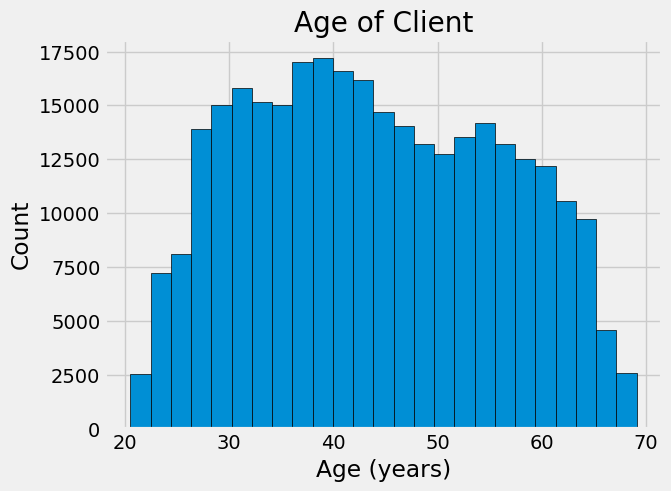

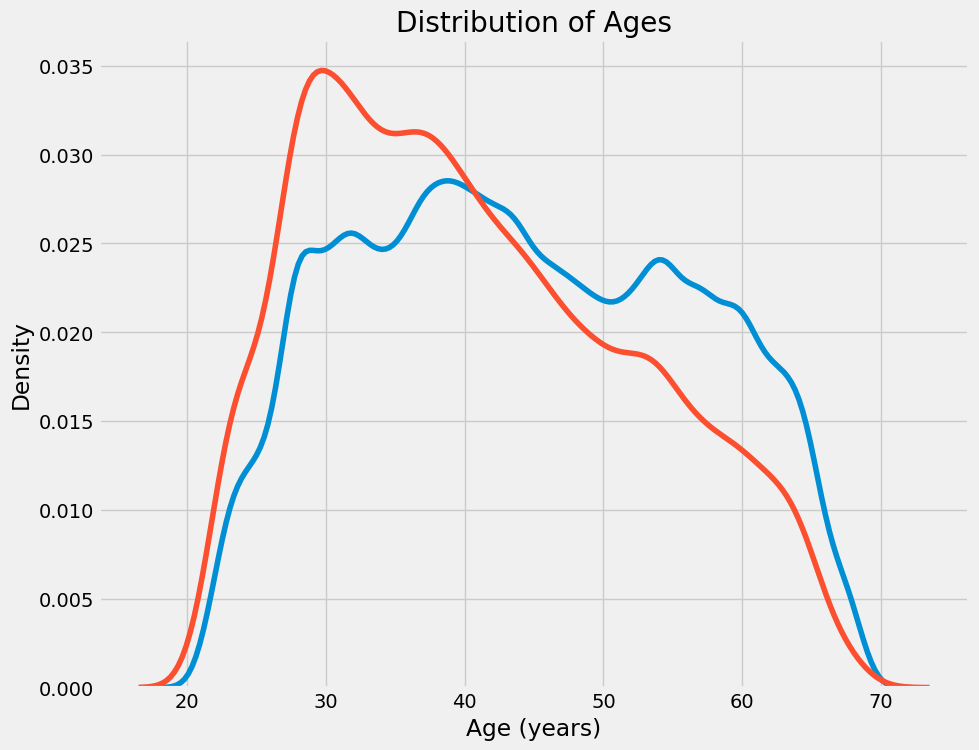

In [53]:
plt.style.use('fivethirtyeight')
plt.hist(app_train_EDA['AGE_YEARS'], edgecolor='k', bins=25)
plt.title('Age of Client'); plt.xlabel('Age (years)'); plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 8))
sns.kdeplot(app_train_EDA.loc[app_train_EDA['TARGET'] == 0, 'AGE_YEARS'], label='target == 0')
sns.kdeplot(app_train_EDA.loc[app_train_EDA['TARGET'] == 1, 'AGE_YEARS'], label='target == 1')
plt.xlabel('Age (years)'); plt.ylabel('Density'); plt.title('Distribution of Ages')
plt.show()

- `DAYS_EMPLOYED`

In [54]:
app_train['DAYS_EMPLOYED'].describe()

count    307511.000000
mean      63815.045904
std      141275.766519
min      -17912.000000
25%       -2760.000000
50%       -1213.000000
75%        -289.000000
max      365243.000000
Name: DAYS_EMPLOYED, dtype: float64

Ça ne semble pas correct ! La valeur maximale (outre le fait qu'elle soit positive) est d'environ 1 000 ans !

Text(0.5, 0, 'Days Employment')

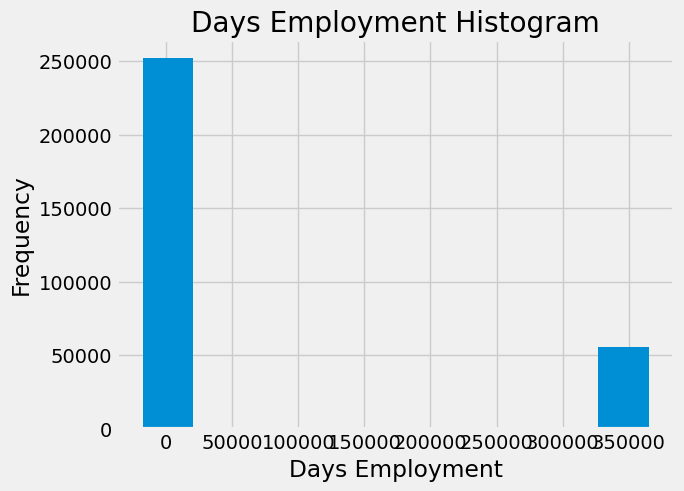

In [55]:
app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram')
plt.xlabel('Days Employment')

Juste par curiosité, sous-représentons les clients anormaux et voyons s'ils ont tendance à avoir des taux de défaut plus élevés ou plus faibles que le reste des clients.

In [56]:
anom = app_train[app_train['DAYS_EMPLOYED'] == 365243]
non_anom = app_train[app_train['DAYS_EMPLOYED'] != 365243]
print('Les défauts de paiement non anormaux sur %0.2f%% des prêts' % (100 * non_anom['TARGET'].mean()))
print('Les anomalies font défaut sur %0.2f%% des prêts' % (100 * anom['TARGET'].mean()))
print("Il y a %d jours d'emploi anormaux" % len(anom))

Les défauts de paiement non anormaux sur 8.66% des prêts
Les anomalies font défaut sur 5.40% des prêts
Il y a 55374 jours d'emploi anormaux


Voilà qui est extrêmement intéressant ! Il s'avère que les anomalies présentent un taux de défaut plus faible.

La gestion des anomalies dépend de la situation, sans règles prédéfinies. L'une des approches les plus sûres consiste à définir les anomalies avec une valeur manquante, puis à les compléter (par imputation) avant l'apprentissage automatique. Dans ce cas, puisque toutes les anomalies ont exactement la même valeur, nous souhaitons les compléter avec la même valeur au cas où tous ces prêts auraient un point commun. Les valeurs anormales semblent avoir une certaine importance ; nous souhaitons donc indiquer au modèle d'apprentissage automatique si nous les avons effectivement renseignées. Pour résoudre ce problème, nous allons compléter les valeurs anormales avec un nombre (np.nan), puis créer une nouvelle colonne booléenne indiquant si la valeur était anormale ou non.

Text(0.5, 0, 'Days Employment')

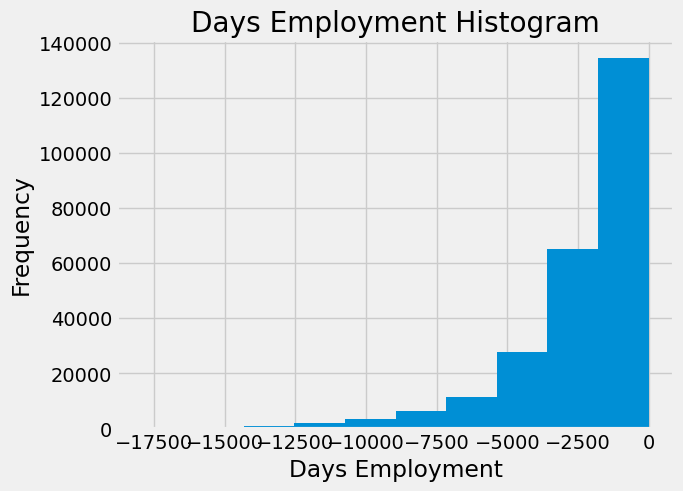

In [57]:
# Create an anomalous flag column
app_train['DAYS_EMPLOYED_ANOM'] = app_train["DAYS_EMPLOYED"] == 365243

# Replace the anomalous values with nan
app_train['DAYS_EMPLOYED'].replace({365243: np.nan}, inplace = True)

app_train['DAYS_EMPLOYED'].plot.hist(title = 'Days Employment Histogram')
plt.xlabel('Days Employment')

La distribution semble beaucoup plus conforme à nos attentes, et nous avons également créé une nouvelle colonne pour indiquer au modèle que ces valeurs étaient initialement anormales (car nous devrons renseigner les valeurs nans avec une valeur, probablement la médiane de la colonne). Les autres colonnes contenant des JOURS dans le dataframe semblent correspondre à nos attentes, sans valeurs aberrantes évidentes.

Il est extrêmement important de noter que toute modification des données d'entraînement doit également être appliquée aux données de test. Nous allons donc créer la nouvelle colonne et renseigner la colonne existante avec np.nan dans les données de test.

In [58]:
app_test['DAYS_EMPLOYED_ANOM'] = app_test["DAYS_EMPLOYED"] == 365243
app_test["DAYS_EMPLOYED"].replace({365243: np.nan}, inplace = True)

print('Il y a %d anomalies dans les données de test sur %d entrées.' % (app_test["DAYS_EMPLOYED_ANOM"].sum(), len(app_test)))

Il y a 9274 anomalies dans les données de test sur 48744 entrées.


#### **2.6. Variable `DAYS_BIRTH` - Effet de l'age sur le remboursement**

In [59]:
app_train['DAYS_BIRTH'] = abs(app_train['DAYS_BIRTH'])
app_train['DAYS_BIRTH'].corr(app_train['TARGET'])

-0.07823930830982709

À mesure que le client vieillit, il existe une relation linéaire négative avec la cible, ce qui signifie qu'avec l'âge, les clients ont tendance à rembourser leurs prêts à temps plus souvent.

Commençons par examiner cette variable. Nous pouvons d'abord créer un histogramme de l'âge. Nous placerons l'axe des abscisses en années pour une meilleure lisibilité du graphique.

Text(0, 0.5, 'Count')

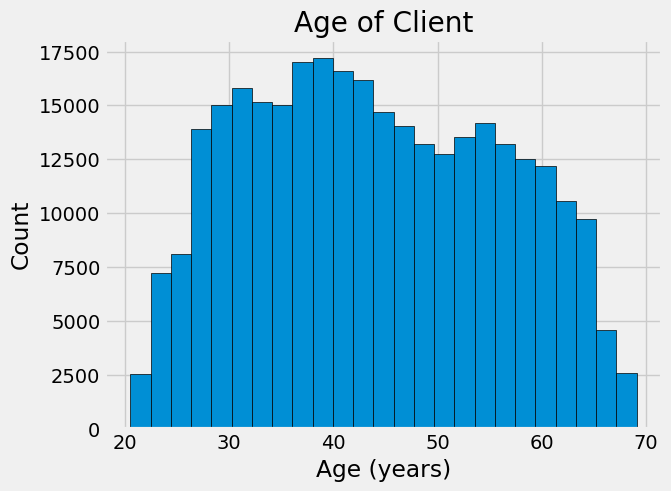

In [60]:
# Set the style of plots
plt.style.use('fivethirtyeight')

# Plot the distribution of ages in years
plt.hist(app_train['DAYS_BIRTH'] / 365, edgecolor = 'k', bins = 25)
plt.title('Age of Client'); plt.xlabel('Age (years)'); plt.ylabel('Count')

En soi, la distribution des âges ne nous apprend pas grand-chose, si ce n'est qu'il n'y a pas de valeurs aberrantes, car tous les âges sont raisonnables. Pour visualiser l'effet de l'âge sur la cible, nous allons maintenant créer un graphique d'estimation de la densité du noyau (KDE) coloré par la valeur de la cible. Un graphique d'estimation de la densité du noyau montre la distribution d'une variable unique et peut être considéré comme un histogramme lissé (il est créé en calculant un noyau, généralement gaussien, à chaque point de données, puis en faisant la moyenne de tous les noyaux individuels pour obtenir une courbe lisse unique). Nous utiliserons le kdeplot de Seaborn pour ce graphique.

Text(0.5, 1.0, 'Distribution of Ages')

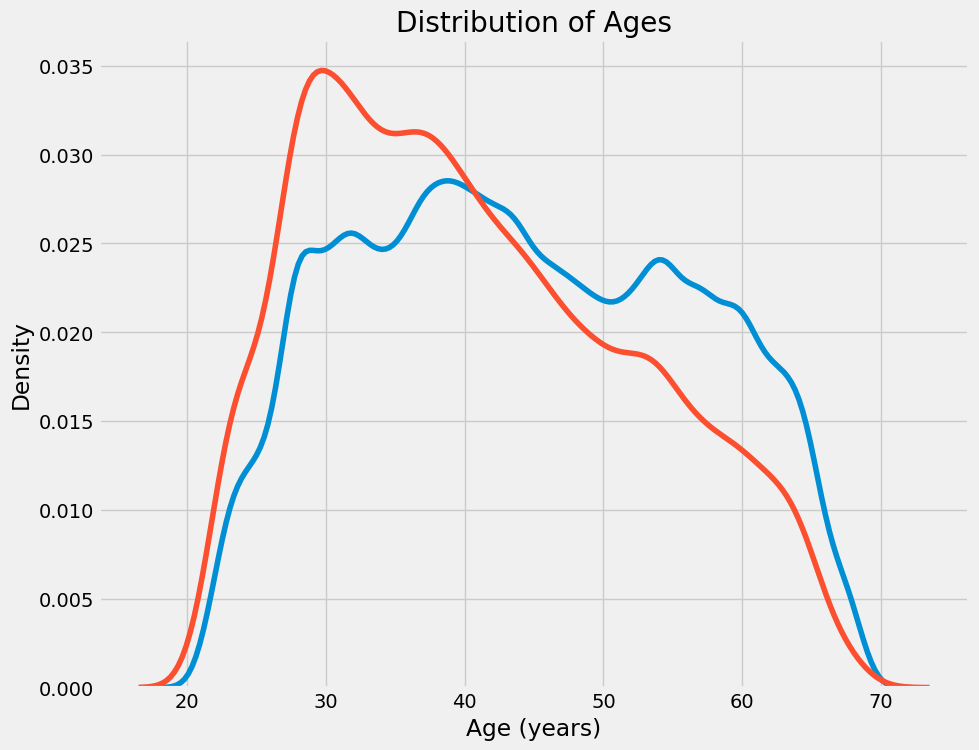

In [61]:
plt.figure(figsize = (10, 8))

# KDE plot of loans that were repaid on time
sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, 'DAYS_BIRTH'] / 365, label = 'target == 0')

# KDE plot of loans which were not repaid on time
sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, 'DAYS_BIRTH'] / 365, label = 'target == 1')

# Labeling of plot
plt.xlabel('Age (years)'); plt.ylabel('Density'); plt.title('Distribution of Ages')

La courbe cible == 1 penche vers les plus jeunes. Bien que cette corrélation ne soit pas significative (coefficient de corrélation de -0,07), cette variable sera probablement utile dans un modèle d'apprentissage automatique, car elle influence la cible. Examinons cette relation sous un autre angle : le taux moyen de non-remboursement des prêts par tranche d'âge.

Pour créer ce graphique, nous découpons d'abord la tranche d'âge en tranches de 5 ans chacune. Ensuite, pour chaque tranche, nous calculons la valeur moyenne de la cible, qui indique le ratio de prêts non remboursés dans chaque tranche d'âge.

In [62]:
# Age information into a separate dataframe
age_data = app_train[['TARGET', 'DAYS_BIRTH']]
age_data['YEARS_BIRTH'] = age_data['DAYS_BIRTH'] / 365

# Bin the age data
age_data['YEARS_BINNED'] = pd.cut(age_data['YEARS_BIRTH'], bins = np.linspace(20, 70, num = 11))
age_data.head(10)

,TARGET,DAYS_BIRTH,YEARS_BIRTH,YEARS_BINNED
0,1,9461,25.920548,"(25.0, 30.0]"
1,0,16765,45.931507,"(45.0, 50.0]"
2,0,19046,52.180822,"(50.0, 55.0]"
3,0,19005,52.068493,"(50.0, 55.0]"
4,0,19932,54.608219,"(50.0, 55.0]"
5,0,16941,46.413699,"(45.0, 50.0]"
6,0,13778,37.747945,"(35.0, 40.0]"
7,0,18850,51.643836,"(50.0, 55.0]"
8,0,20099,55.065753,"(55.0, 60.0]"
9,0,14469,39.641096,"(35.0, 40.0]"


In [63]:
# Group by the bin and calculate averages
age_groups  = age_data.groupby('YEARS_BINNED').mean()
age_groups

,TARGET,DAYS_BIRTH,YEARS_BIRTH
YEARS_BINNED,,,
"(20.0, 25.0]",0.123036,8532.795625,23.377522
"(25.0, 30.0]",0.111436,10155.219250,27.822518
"(30.0, 35.0]",0.102814,11854.848377,32.479037
"(35.0, 40.0]",0.089414,13707.908253,37.555913
"(40.0, 45.0]",0.078491,15497.661233,42.459346
"(45.0, 50.0]",0.074171,17323.900441,47.462741
"(50.0, 55.0]",0.066968,19196.494791,52.593136
"(55.0, 60.0]",0.055314,20984.262742,57.491131
"(60.0, 65.0]",0.052737,22780.547460,62.412459


Text(0.5, 1.0, 'Failure to Repay by Age Group')

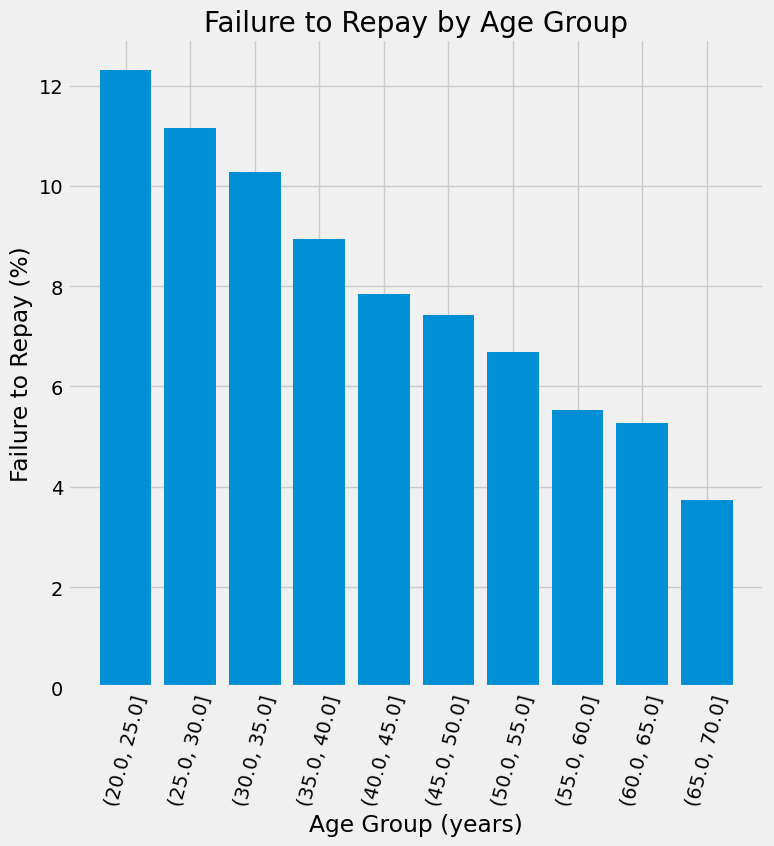

In [64]:
plt.figure(figsize = (8, 8))

# Graph the age bins and the average of the target as a bar plot
plt.bar(age_groups.index.astype(str), 100 * age_groups['TARGET'])

# Plot labeling
plt.xticks(rotation = 75); plt.xlabel('Age Group (years)'); plt.ylabel('Failure to Repay (%)')
plt.title('Failure to Repay by Age Group')

La tendance est claire : les jeunes demandeurs sont plus susceptibles de ne pas rembourser leur prêt ! Le taux de défaut de remboursement est supérieur à 10 % pour les trois tranches d'âge les plus jeunes et inférieur à 5 % pour la tranche d'âge la plus âgée.

Ces informations pourraient être directement utilisées par la banque : les jeunes clients étant moins susceptibles de rembourser leur prêt, il serait peut-être judicieux de leur fournir davantage d'accompagnement ou de conseils en matière de planification financière. Cela ne signifie pas que la banque doive discriminer les jeunes clients, mais qu'il serait judicieux de prendre des mesures préventives pour les aider à rembourser à temps.

#### **2.7. Variable `EXT_SOURCE`**

In [65]:
# Extract the EXT_SOURCE variables and show correlations
ext_data = app_train[['TARGET', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH']]
ext_data_corrs = ext_data.corr()
ext_data_corrs

,TARGET,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH
TARGET,1.000000,-0.155317,-0.160472,-0.178919,-0.078239
EXT_SOURCE_1,-0.155317,1.000000,0.213982,0.186846,0.600610
EXT_SOURCE_2,-0.160472,0.213982,1.000000,0.109167,0.091996
EXT_SOURCE_3,-0.178919,0.186846,0.109167,1.000000,0.205478
DAYS_BIRTH,-0.078239,0.600610,0.091996,0.205478,1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

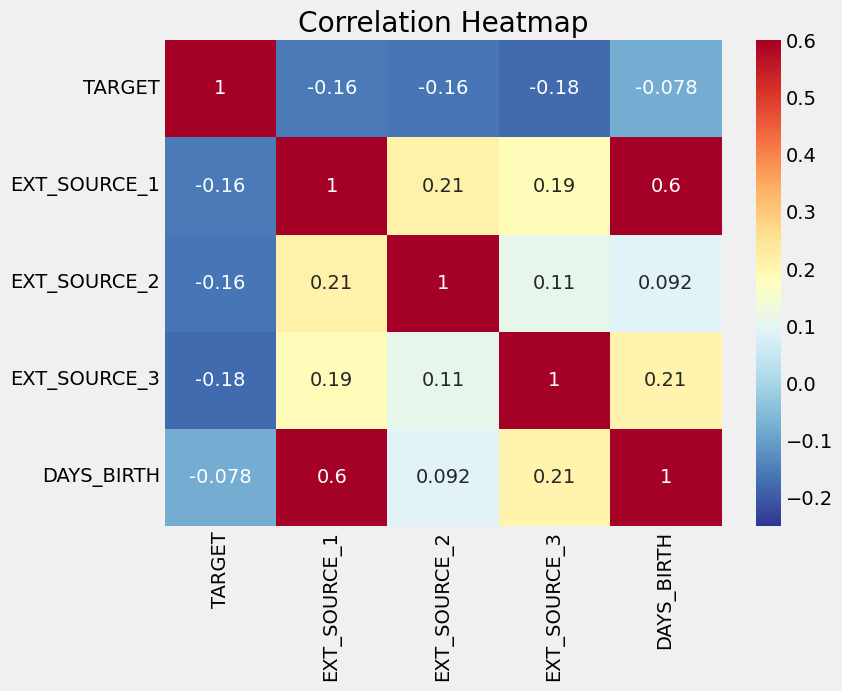

In [66]:
plt.figure(figsize = (8, 6))

# Heatmap of correlations
sns.heatmap(ext_data_corrs, cmap = plt.cm.RdYlBu_r, vmin = -0.25, annot = True, vmax = 0.6)
plt.title('Correlation Heatmap')

Les trois caractéristiques EXT_SOURCE présentent une corrélation négative avec la cible, ce qui indique qu'à mesure que la valeur de EXT_SOURCE augmente, le client est plus susceptible de rembourser son prêt. On constate également que DAYS_BIRTH est positivement corrélé à EXT_SOURCE_1, ce qui indique que l'âge du client pourrait être l'un des facteurs de ce score.

Examinons ensuite la distribution de chacune de ces caractéristiques, colorée par la valeur de la cible. Cela nous permettra de visualiser l'effet de cette variable sur la cible.

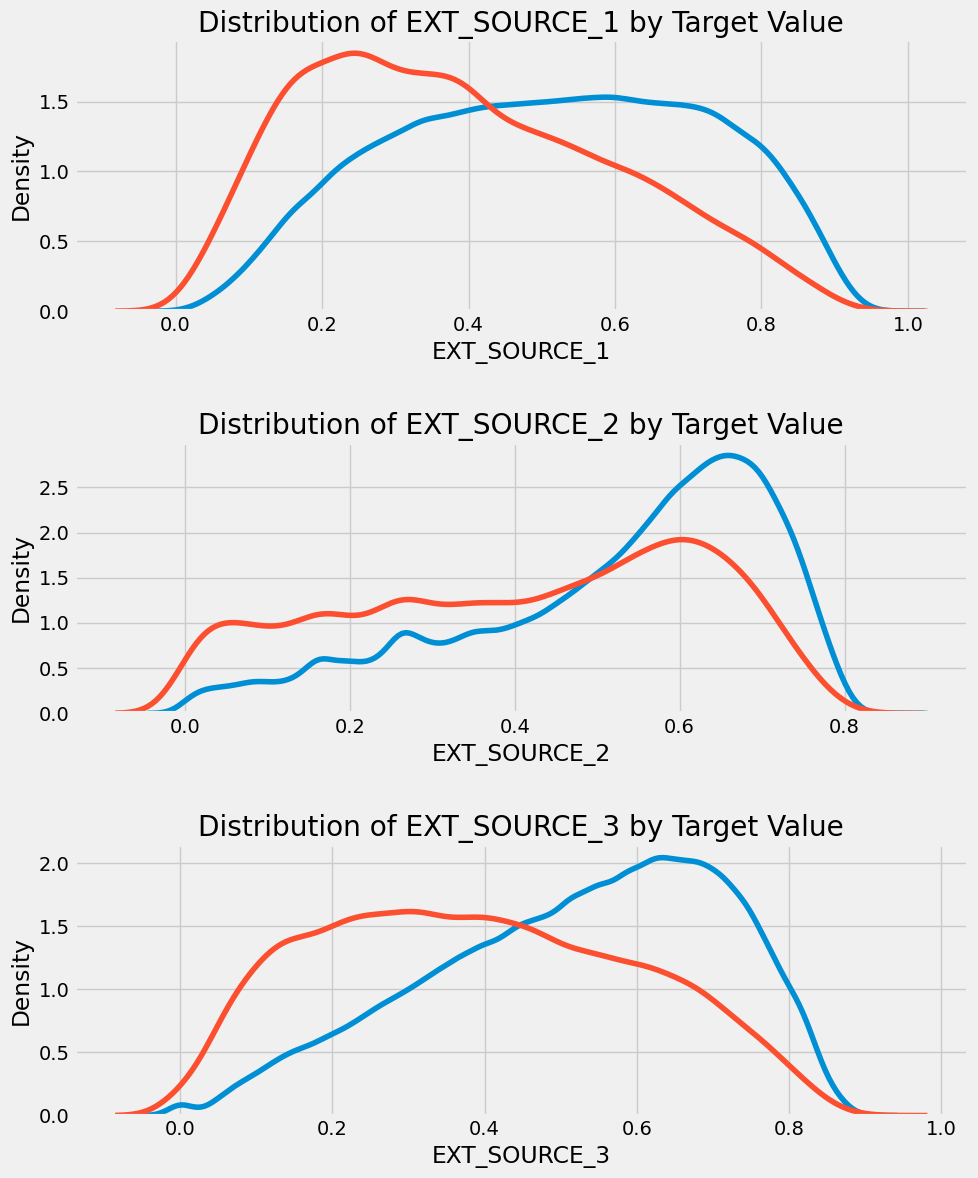

In [67]:
plt.figure(figsize = (10, 12))

# iterate through the sources
for i, source in enumerate(['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    
    # create a new subplot for each source
    plt.subplot(3, 1, i + 1)
    # plot repaid loans
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, source], label = 'target == 0')
    # plot loans that were not repaid
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, source], label = 'target == 1')
    
    # Label the plots
    plt.title('Distribution of %s by Target Value' % source)
    plt.xlabel('%s' % source); plt.ylabel('Density')
    
plt.tight_layout(h_pad = 2.5)

EXT_SOURCE_3 displays the greatest difference between the values of the target. We can clearly see that this feature has some relationship to the likelihood of an applicant to repay a loan. The relationship is not very strong (in fact they are all considered very weak, but these variables will still be useful for a machine learning model to predict whether or not an applicant will repay a loan on time).

#### **2.8. Variable `OCCUPATION_TYPE`**

Cette variable indique la catégorie socio-professionnelle du demandeur



In [68]:
p1 = (app_train.loc[app_train['TARGET'] == 1, 'OCCUPATION_TYPE']
      .value_counts(normalize=True) * 100)
p0 = (app_train.loc[app_train['TARGET'] == 0, 'OCCUPATION_TYPE']
      .value_counts(normalize=True) * 100)


In [69]:
cats = sorted(set(p0.index).union(p1.index), key=lambda c: p1.get(c, 0), reverse=True)

In [70]:
p1 = p1.reindex(cats).fillna(0)
p0 = p0.reindex(cats).fillna(0)

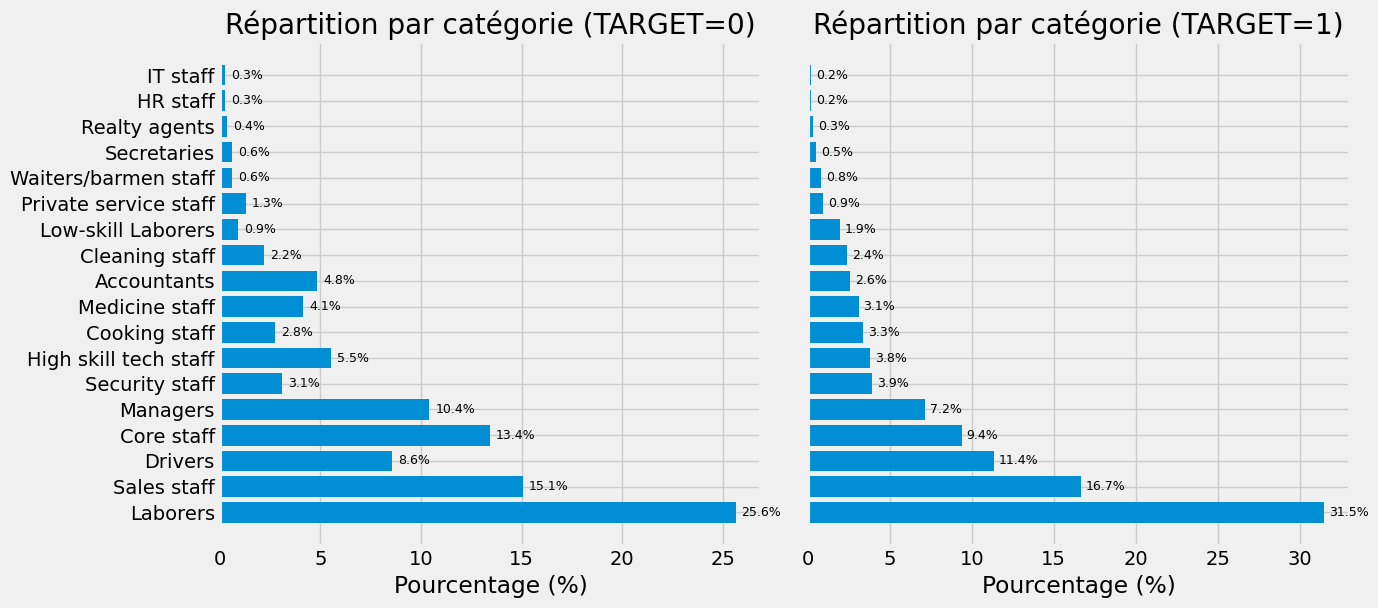

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, len(cats) * 0.35)), sharey=True)

axes[0].barh(cats, p0.values)
axes[0].set_title("Répartition par catégorie (TARGET=0)")
axes[0].set_xlabel("Pourcentage (%)")
axes[0].invert_yaxis()  # catégorie la plus élevée en haut

axes[1].barh(cats, p1.values)
axes[1].set_title("Répartition par catégorie (TARGET=1)")
axes[1].set_xlabel("Pourcentage (%)")
axes[1].invert_yaxis()

for ax in axes:
    # petites annotations de valeurs au bout des barres
    for y, v in enumerate((p0 if ax is axes[0] else p1).values):
        ax.text(v + 0.3, y, f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

Pour la préparation des données nous nous baserons sur le kernel Kaggle suivant : [LightGBM with Simple Features](https://www.kaggle.com/code/jsaguiar/lightgbm-with-simple-features/script)

#### **2.9. One hot encoding, FI et merge global**

- `application_train.csv` et `application_test.csv`

In [72]:
# Re-load propre pour éviter l’effet de bord EDA
app_train = pd.read_csv(os.path.join(DATA_DIR, "application_train.csv"))
app_test  = pd.read_csv(os.path.join(DATA_DIR, "application_test.csv"))

In [73]:
for df_ in (app_train, app_test):
    df_['DAYS_EMPLOYED_ANOM'] = (df_['DAYS_EMPLOYED'] == 365243)
    df_['DAYS_EMPLOYED'] = df_['DAYS_EMPLOYED'].replace(365243, np.nan)

In [74]:
app_train['AGE_YEARS'] = (app_train['DAYS_BIRTH'].abs() / 365).astype(float)

In [75]:
nan_as_category = False

print(f"Train : {app_train.shape}, Test : {app_test.shape}")
base = pd.concat([app_train, app_test], axis=0, ignore_index=True)

# Optional: retirer les XNA en genre
if 'CODE_GENDER' in base.columns:
    base = base[base['CODE_GENDER'] != 'XNA']

# Factorize binaires listées (0 ou 1; 2 categories)
for binary_feature in ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'EMERGENCYSTATE_MODE']:
    if binary_feature in base.columns:
        base[binary_feature], _ = pd.factorize(base[binary_feature])

# One-hot des autres catégorielles
base, base_cat_cols = one_hot_encoder(base, nan_as_category=False)

Train : (307511, 124), Test : (48744, 122)


In [76]:
# Ratios simples (Application)
if {'DAYS_EMPLOYED','DAYS_BIRTH'}.issubset(base.columns):
    base['DAYS_EMPLOYED_PERC'] = base['DAYS_EMPLOYED'] / base['DAYS_BIRTH']
if {'AMT_INCOME_TOTAL','AMT_CREDIT'}.issubset(base.columns):
    base['INCOME_CREDIT_PERC'] = base['AMT_INCOME_TOTAL'] / base['AMT_CREDIT']
if {'AMT_INCOME_TOTAL','CNT_FAM_MEMBERS'}.issubset(base.columns):
    base['INCOME_PER_PERSON'] = base['AMT_INCOME_TOTAL'] / base['CNT_FAM_MEMBERS']
if {'AMT_ANNUITY','AMT_INCOME_TOTAL'}.issubset(base.columns):
    base['ANNUITY_INCOME_PERC'] = base['AMT_ANNUITY'] / base['AMT_INCOME_TOTAL']
if {'AMT_ANNUITY','AMT_CREDIT'}.issubset(base.columns):
    base['PAYMENT_RATE'] = base['AMT_ANNUITY'] / base['AMT_CREDIT']

- Chargement des autres tables secondaires + agrégations

In [77]:
# --- Bureau / Bureau_balance ---
bureau = pd.read_csv(os.path.join(DATA_DIR, "bureau.csv"))
bureau_balance = pd.read_csv(os.path.join(DATA_DIR, "bureau_balance.csv"))

bureau_balance, bureau_balance_cat = one_hot_encoder(bureau_balance, nan_as_category=True)
bureau, bureau_cat = one_hot_encoder(bureau, nan_as_category=True)

In [78]:
# Agrégations bureau_balance → bureau
bureau_balance_agg = bureau_balance.groupby('SK_ID_BUREAU').agg({
    'MONTHS_BALANCE': ['min', 'max', 'size'],
    **{c: ['mean'] for c in bureau_balance_cat}
})
bureau_balance_agg.columns = pd.Index([f"{a}_{b.upper()}" for a, b in bureau_balance_agg.columns])
bureau = bureau.join(bureau_balance_agg, on='SK_ID_BUREAU', how='left').drop(columns=['SK_ID_BUREAU'])


In [79]:
# Agrégations finales bureau par SK_ID_CURR
num_aggs = {
    'DAYS_CREDIT': ['min', 'max', 'mean', 'var'],
    'DAYS_CREDIT_ENDDATE': ['min', 'max', 'mean'],
    'DAYS_CREDIT_UPDATE': ['mean'],
    'CREDIT_DAY_OVERDUE': ['max', 'mean'],
    'AMT_CREDIT_MAX_OVERDUE': ['mean'],
    'AMT_CREDIT_SUM': ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_DEBT': ['max', 'mean', 'sum'],
    'AMT_CREDIT_SUM_OVERDUE': ['mean'],
    'AMT_CREDIT_SUM_LIMIT': ['mean', 'sum'],
    'AMT_ANNUITY': ['max', 'mean'],
    'CNT_CREDIT_PROLONG': ['sum'],
    'MONTHS_BALANCE_MIN': ['min'],
    'MONTHS_BALANCE_MAX': ['max'],
    'MONTHS_BALANCE_SIZE': ['mean', 'sum']
}
cat_aggs = {c: ['mean'] for c in bureau_cat}
cat_aggs.update({f"{c}_MEAN": ['mean'] for c in bureau_balance_cat})

bureau_agg = bureau.groupby('SK_ID_CURR').agg({**num_aggs, **cat_aggs})
bureau_agg.columns = pd.Index([f"BURO_{a}_{b.upper()}" for a, b in bureau_agg.columns])

# Active / Closed
if 'CREDIT_ACTIVE_Active' in bureau.columns:
    active = bureau[bureau['CREDIT_ACTIVE_Active'] == 1]
    active_agg = active.groupby('SK_ID_CURR').agg(num_aggs)
    active_agg.columns = pd.Index([f"ACTIVE_{a}_{b.upper()}" for a, b in active_agg.columns])
    bureau_agg = bureau_agg.join(active_agg, how='left')

if 'CREDIT_ACTIVE_Closed' in bureau.columns:
    closed = bureau[bureau['CREDIT_ACTIVE_Closed'] == 1]
    closed_agg = closed.groupby('SK_ID_CURR').agg(num_aggs)
    closed_agg.columns = pd.Index([f"CLOSED_{a}_{b.upper()}" for a, b in closed_agg.columns])
    bureau_agg = bureau_agg.join(closed_agg, how='left')

In [80]:
# --- Previous ---
prev = pd.read_csv(os.path.join(DATA_DIR, "previous_application.csv"))
for c in ['DAYS_FIRST_DRAWING','DAYS_FIRST_DUE','DAYS_LAST_DUE_1ST_VERSION','DAYS_LAST_DUE','DAYS_TERMINATION']:
    if c in prev.columns:
        prev[c] = prev[c].replace(365243, np.nan)

if {'AMT_APPLICATION','AMT_CREDIT'}.issubset(prev.columns):
    prev['APP_CREDIT_PERC'] = prev['AMT_APPLICATION'] / prev['AMT_CREDIT']

prev, prev_cat_cols = one_hot_encoder(prev, nan_as_category=True)
num_aggs_prev = {
    'AMT_ANNUITY': ['min','max','mean'],
    'AMT_APPLICATION': ['min','max','mean'],
    'AMT_CREDIT': ['min','max','mean'],
    'APP_CREDIT_PERC': ['min','max','mean','var'],
    'AMT_DOWN_PAYMENT': ['min','max','mean'],
    'AMT_GOODS_PRICE': ['min','max','mean'],
    'HOUR_APPR_PROCESS_START': ['min','max','mean'],
    'RATE_DOWN_PAYMENT': ['min','max','mean'],
    'DAYS_DECISION': ['min','max','mean'],
    'CNT_PAYMENT': ['mean','sum'],
}
cat_aggs_prev = {c: ['mean'] for c in prev_cat_cols}
prev_agg = prev.groupby('SK_ID_CURR').agg({**num_aggs_prev, **cat_aggs_prev})
prev_agg.columns = pd.Index([f"PREV_{a}_{b.upper()}" for a, b in prev_agg.columns])

if 'NAME_CONTRACT_STATUS_Approved' in prev.columns:
    approved = prev[prev['NAME_CONTRACT_STATUS_Approved'] == 1]
    app_agg = approved.groupby('SK_ID_CURR').agg(num_aggs_prev)
    app_agg.columns = pd.Index([f"APPROVED_{a}_{b.upper()}" for a, b in app_agg.columns])
    prev_agg = prev_agg.join(app_agg, how='left')

if 'NAME_CONTRACT_STATUS_Refused' in prev.columns:
    refused = prev[prev['NAME_CONTRACT_STATUS_Refused'] == 1]
    ref_agg = refused.groupby('SK_ID_CURR').agg(num_aggs_prev)
    ref_agg.columns = pd.Index([f"REFUSED_{a}_{b.upper()}" for a, b in ref_agg.columns])
    prev_agg = prev_agg.join(ref_agg, how='left')

In [81]:
# --- POS_CASH ---
pos = pd.read_csv(os.path.join(DATA_DIR, "POS_CASH_balance.csv"))
pos, pos_cat_cols = one_hot_encoder(pos, nan_as_category=True)
aggs_pos = {'MONTHS_BALANCE':['max','mean','size'], 'SK_DPD':['max','mean'], 'SK_DPD_DEF':['max','mean']}
aggs_pos.update({c:['mean'] for c in pos_cat_cols})
pos_agg = pos.groupby('SK_ID_CURR').agg(aggs_pos)
pos_agg.columns = pd.Index([f"POS_{a}_{b.upper()}" for a, b in pos_agg.columns])
pos_agg['POS_COUNT'] = pos.groupby('SK_ID_CURR').size()

In [82]:
# --- Installments ---
ins = pd.read_csv(os.path.join(DATA_DIR, "installments_payments.csv"))
ins['PAYMENT_PERC'] = ins['AMT_PAYMENT'] / ins['AMT_INSTALMENT']
ins['PAYMENT_DIFF'] = ins['AMT_INSTALMENT'] - ins['AMT_PAYMENT']
ins['DPD'] = (ins['DAYS_ENTRY_PAYMENT'] - ins['DAYS_INSTALMENT']).clip(lower=0)
ins['DBD'] = (ins['DAYS_INSTALMENT'] - ins['DAYS_ENTRY_PAYMENT']).clip(lower=0)
aggs_ins = {
    'NUM_INSTALMENT_VERSION':['nunique'],
    'DPD':['max','mean','sum'],
    'DBD':['max','mean','sum'],
    'PAYMENT_PERC':['max','mean','sum','var'],
    'PAYMENT_DIFF':['max','mean','sum','var'],
    'AMT_INSTALMENT':['max','mean','sum'],
    'AMT_PAYMENT':['min','max','mean','sum'],
    'DAYS_ENTRY_PAYMENT':['max','mean','sum']
}
ins, ins_cat_cols = one_hot_encoder(ins, nan_as_category=True)
aggs_ins.update({c:['mean'] for c in ins_cat_cols})
ins_agg = ins.groupby('SK_ID_CURR').agg(aggs_ins)
ins_agg.columns = pd.Index([f"INSTAL_{a}_{b.upper()}" for a, b in ins_agg.columns])
ins_agg['INSTAL_COUNT'] = ins.groupby('SK_ID_CURR').size()

In [83]:
# --- Credit Card ---
cc = pd.read_csv(os.path.join(DATA_DIR, "credit_card_balance.csv"))
cc, cc_cat_cols = one_hot_encoder(cc, nan_as_category=True)
if 'SK_ID_PREV' in cc.columns:
    cc = cc.drop(columns=['SK_ID_PREV'])
cc_agg = cc.groupby('SK_ID_CURR').agg(['min','max','mean','sum','var'])
cc_agg.columns = pd.Index([f"CC_{a}_{b.upper()}" for a, b in cc_agg.columns])
cc_agg['CC_COUNT'] = cc.groupby('SK_ID_CURR').size()

- Merge

In [84]:
# --- Merge global ---
df = base.copy()
for left in (bureau_agg, prev_agg, pos_agg, ins_agg, cc_agg):
    df = df.join(left, on='SK_ID_CURR', how='left')

In [85]:
print("df merged shape:", df.shape)

df merged shape: (356251, 797)


In [86]:
df.to_csv(os.path.join(DATA_DIR, 'df_merged.csv'), index=False)

#### **2.10. Split train/test et drop colonnes**

In [87]:
# On conserve TARGET tel qu'il est (présent uniquement pour le segment train)
is_train = df['TARGET'].notna()
train_df = df.loc[is_train].reset_index(drop=True)
test_df  = df.loc[~is_train].reset_index(drop=True)

In [88]:
# Drop colonnes très incomplètes (seuil 60%)
missing_pct = train_df.isnull().mean() * 100  # calcul sur train uniquement
cols_drop = missing_pct[missing_pct > 60].index.tolist()
print(f"Colonnes drop (>60% NaN): {len(cols_drop)}")

Colonnes drop (>60% NaN): 212


In [89]:
train_df = train_df.drop(columns=cols_drop)
test_df  = test_df.drop(columns=cols_drop)
print("Train after drop:", train_df.shape, "Test after drop:", test_df.shape)

Train after drop: (307507, 585) Test after drop: (48744, 585)


#### **2.11. Evaluation générique en CV (AUC/AP/Gain) pour Pipelines**

Déséquilibre des coûts métier et fonction de gain

Il existe un **déséquilibre de coûts** entre :
- **Faux négatif (FN)** : *mauvais client prédit bon* → crédit accordé → **perte de capital**.
- **Faux positif (FP)** : *bon client prédit mauvais* → crédit refusé → **manque à gagner** (marge non réalisée).

Hypothèse : le **coût d’un FN est 10×** celui d’un FP.

--

Fonction de gain (positif = valeur créée, négatif = perte)

- **Vrais positifs (TP)** – bons clients correctement acceptés : **+1**
- **Faux positifs (FP)** – bons clients refusés à tort : **−1**
- **Faux négatifs (FN)** – mauvais clients acceptés : **−10**
- **Vrais négatifs (TN)** – mauvais clients correctement refusés : **0** (neutre)

Formule : Gain total = 1xTP − 1xFP − 10xFN
(Les TN sont ignorés.)

> **Note :** ces pondérations peuvent être **ajustées** selon les retours métier, le portefeuille, la conjoncture et le comportement observé à l’entraînement et en production (ex. calibration des seuils).


Petit test avec des fausses données : 

In [93]:
# Jeu de données simple et parfaitement bien prédit
# 1 = bon client, 0 = mauvais client
y_true = np.array([1,0,1,0,1,0,1,0,1,0])  # 5 bons, 5 mauvais
y_pred_perfect = y_true.copy()            # prédictions parfaites

# Gain de base (parfait)
base_gain, base_break = compute_business_score(y_true, y_pred_perfect, return_breakdown=True)
base_TP, base_FP, base_FN, base_TN = base_break["TP"], base_break["FP"], base_break["FN"], base_break["TN"]

# Scénario 1 : introduire 1 faux positif (changer une prédiction sur un vrai 0 -> 1)
y_pred_fp = y_pred_perfect.copy()
idx_fp = np.where(y_true == 0)[0][0]  # prendre un "mauvais client"
y_pred_fp[idx_fp] = 1                 # le modèle l'accepte à tort
gain_fp, br_fp = compute_business_score(y_true, y_pred_fp, return_breakdown=True)

# Scénario 2 : introduire 1 faux négatif (changer une prédiction sur un vrai 1 -> 0)
y_pred_fn = y_pred_perfect.copy()
idx_fn = np.where(y_true == 1)[0][0]  # prendre un "bon client"
y_pred_fn[idx_fn] = 0                 # le modèle le refuse à tort
gain_fn, br_fn = compute_business_score(y_true, y_pred_fn, return_breakdown=True)

# Récapitulatif
df_test = pd.DataFrame([
    {
        "Scenario": "Parfait (référence)",
        "TP": base_TP, "FP": base_FP, "FN": base_FN, "TN": base_TN,
        "Gain": base_gain, "Δ vs base": 0
    },
    {
        "Scenario": "Ajouter 1 faux positif",
        "TP": br_fp["TP"], "FP": br_fp["FP"], "FN": br_fp["FN"], "TN": br_fp["TN"],
        "Gain": gain_fp, "Δ vs base": gain_fp - base_gain
    },
    {
        "Scenario": "Ajouter 1 faux négatif",
        "TP": br_fn["TP"], "FP": br_fn["FP"], "FN": br_fn["FN"], "TN": br_fn["TN"],
        "Gain": gain_fn, "Δ vs base": gain_fn - base_gain
    },
])

print(df_test.to_string(index=False))

              Scenario  TP  FP  FN  TN  Gain  Δ vs base
   Parfait (référence)   5   0   0   5   5.0        0.0
Ajouter 1 faux positif   5   1   0   4   4.0       -1.0
Ajouter 1 faux négatif   4   0   1   5  -6.0      -11.0


On voit bien que le gain diminue fortement en présence d'un faux négatif, et un peu moins en présence d'un faux négatif.

Associé à notre fonction score métier, nous mettrons également en oeuvre la métrique d'aire sous la courbe AUC

In [94]:
# X/y (numériques+bool uniquement)
y = train_df["TARGET"].astype(int).values
X = train_df.drop(columns=["TARGET"]).select_dtypes(include=[np.number, "bool"]).copy()

In [95]:
def make_lgbm_pipeline(impute_strategy: str):
    return Pipeline(steps=[
        ("cleanup",  FunctionTransformer(_cleanup_inf_to_nan, validate=False)),
        ("sanitize", FunctionTransformer(sanitize_colnames_for_lgbm, validate=False)),  # << NEW
        ("imputer",  SimpleImputer(strategy=("most_frequent" if impute_strategy=="mode" else impute_strategy))),
        ("lgbm",     LGBMClassifier(
            n_estimators=5000,
            learning_rate=0.03,
            num_leaves=48,
            subsample=0.8,
            colsample_bytree=0.8,
            max_depth=-1,
            min_child_samples=50,
            n_jobs=-1,
            random_state=42,
            force_col_wise=True
        ))
    ])


In [96]:
def evaluate_cv(model, X, y, name: str,
                cv=None, tp_coeff=1.0, fp_coeff=-1.0, fn_coeff=-10.0):
    """
    Évalue un (Imb)Pipeline en CV :
      - En TRAIN : applique prépro + samplers (fit_resample)
      - En VALIDATION : applique uniquement les transforms (jamais de resampling)
      - Entraîne LGBM directement sur X_transf déjà prêt (plus d'`eval_set` brut)
    """
    if cv is None:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Sépare le pipeline en (prépro) et (lgbm final)
    assert hasattr(model, "steps") and len(model.steps) >= 1, "Il faut un pipeline avec au moins 1 étape."
    pre_steps = model.steps[:-1]
    lgbm = clone(model.steps[-1][1])

    metrics_accu = defaultdict(list)

    for fold, (tr, va) in enumerate(cv.split(X, y), 1):
        X_tr, X_va = X.iloc[tr], X.iloc[va]
        y_tr, y_va = y[tr], y[va]

        # 1) Fit + transform (et resample si SMOTE) sur TRAIN
        X_tr_t, y_tr_t, fitted_steps = _fit_prepro_steps(pre_steps, X_tr, y_tr)

        # 2) Transform ONLY (sans resample) sur VALIDATION
        X_va_t = _apply_prepro_steps_inference(fitted_steps, X_va)

        # 3) Fit LGBM directement sur les matrices transformées
        lgbm_fit = clone(lgbm)
        # petite sécurité pour jeux larges/sparses
        try:
            lgbm_fit.set_params(force_col_wise=True)
        except Exception:
            pass

        lgbm_fit.fit(
            X_tr_t, y_tr_t,
            eval_set=[(X_va_t, y_va)],
            eval_metric="auc",
            callbacks=[early_stopping(200), log_evaluation(period=0)]
        )

        proba_va = lgbm_fit.predict_proba(X_va_t)[:, 1]
        auc = roc_auc_score(y_va, proba_va)
        ap  = average_precision_score(y_va, proba_va)
        thr, gain_best = best_threshold_for_business(y_va, proba_va, tp_coeff, fp_coeff, fn_coeff)
        gain_05 = compute_business_score(y_va, (proba_va >= 0.5).astype(int), tp_coeff, fp_coeff, fn_coeff)

        metrics_accu["fold"].append(fold)
        metrics_accu["auc_roc"].append(auc)
        metrics_accu["ap_pr"].append(ap)
        metrics_accu["best_thr"].append(thr)
        metrics_accu["gain@best_thr"].append(gain_best)
        metrics_accu["gain@0.5"].append(gain_05)

        print(f"[{name}] Fold {fold}: AUC={auc:.4f} | AP={ap:.4f} | gain@best={gain_best:.1f} | thr={thr:.3f}")

    out = pd.DataFrame(metrics_accu)
    print(f"\n==== {name} (moyennes) ====")
    print(out.mean(numeric_only=True).to_frame("mean").T.round(4))
    return out


In [97]:
results = {}
for strat in ["mean", "median", "mode"]:
    pipe = make_lgbm_pipeline(strat)
    print(f"\n### Évaluation LGBM + imputer='{strat}'")
    res = evaluate_cv(pipe, X, y, name=f"LGBM+{strat}")
    results[strat] = res.mean(numeric_only=True)


### Évaluation LGBM + imputer='mean'
[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 62380
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 550
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[906]	valid_0's auc: 0.782751	valid_0's binary_logloss: 0.238219
[LGBM+mean] Fold 1: AUC=0.7828 | AP=0.2785 | gain@best=-26894.0 | thr=0.074
[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 62499
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 551
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
Training until validation scores don't improve for 2

In [98]:
summary = (pd.DataFrame(results)
           .T[['auc_roc','ap_pr','gain@best_thr','best_thr','gain@0.5']]
           .sort_values('auc_roc', ascending=False))
print("\nComparaison des stratégies d'imputation (moyennes CV) :")
display(summary)


Comparaison des stratégies d'imputation (moyennes CV) :


,auc_roc,ap_pr,gain@best_thr,best_thr,gain@0.5
mode,0.787414,0.280270,-26601.0,0.075210,-47363.0
median,0.787291,0.280447,-26461.0,0.077465,-47346.8
mean,0.786606,0.278811,-26591.6,0.075993,-47365.2


In [99]:
best_impute = summary.index[0]
print("➡️ Stratégie d'imputation retenue :", best_impute)

➡️ Stratégie d'imputation retenue : mode


Les trois stratégies donnent des performances quasi identiques → le modèle est très robuste au choix d’imputation, ce qui est une bonne nouvelle (bonne stabilité).

Légère supériorité du mode → d'ou le fait de le retenir.

AUC ≈ 0.79 et AP ≈ 0.28 → c’est une bonne base pour un modèle de scoring crédit, souvent entre 0.75 et 0.82 pour ce dataset (Home Credit).

Le seuil optimal est très bas (≈ 0.075), ce qui indique :
- que la classe positive (“défaut de paiement”) est rare ;
- et que pour maximiser le “gain métier”, il faut être très sensible : beaucoup de rejets potentiels pour limiter les pertes.

Les gains négatifs indiquent que les coefficients de coût (tp/tn/fp/fn) sont probablement trop sévères :
→ il faudra les recalibrer avant l’évaluation finale MLflow, sinon même un bon modèle affichera toujours un gain < 0.

#### **2.12. Comparaison déséquilibre des classes : baseline vs SMOTE vs scale_pos_weight**

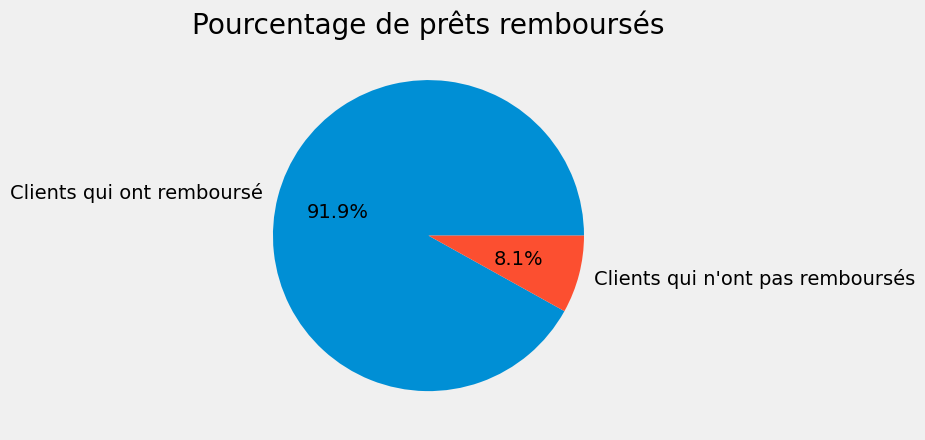

In [100]:
fig = plt.figure()
# Calculate the percentage of each class and plot it into a pie
plt.pie(train_df["TARGET"].value_counts()/train_df.shape[0]*100,
        autopct='%1.1f%%',
        labels=["Clients qui ont remboursé", "Clients qui n'ont pas remboursés"]
       )
plt.title('Pourcentage de prêts remboursés')
plt.show()

La difficulté de travailler avec des jeux de données déséquilibrés réside dans le fait que la plupart des techniques d'apprentissage automatique ignorent la classe minoritaire et, par conséquent, produisent de faibles performances sur celle-ci, alors que c'est généralement cette performance qui est la plus importante.

Une approche pour gérer les jeux de données déséquilibrés consiste à suréchantillonner la classe minoritaire. La méthode la plus simple consiste à dupliquer des exemples dans la classe minoritaire, bien que ces exemples n'apportent aucune information nouvelle au modèle. De nouveaux exemples peuvent être synthétisés à partir des exemples existants. Il s'agit d'une forme d'augmentation des données pour la classe minoritaire, appelée technique de suréchantillonnage synthétique des minorités, ou SMOTE.

En plus des techniques de rééchantillonnage comme SMOTE, LightGBM permet de gérer le déséquilibre directement dans l’apprentissage grâce au paramètre `scale_pos_weight`. Ce dernier ajuste le poids de la classe minoritaire dans la fonction de perte pour lui donner plus d’importance. Il est généralement défini comme : `scale_pos_weight = nb_classes_majoritaires / nb_classes_minoritaires`, ce qui évite de modifier les données d’entraînement.

- Comparaison des méthodes LGBM et SMOTE

In [101]:
# Baseline (reutilise best_impute)
baseline = make_lgbm_pipeline(best_impute)
_ = evaluate_cv(baseline, X, y, name=f"Baseline (imputer={best_impute})")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 62190
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 535
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[771]	valid_0's auc: 0.783735	valid_0's binary_logloss: 0.237904
[Baseline (imputer=mode)] Fold 1: AUC=0.7837 | AP=0.2795 | gain@best=-26600.0 | thr=0.080
[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 62316
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 535
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
Training until validation scores don't improve for 200 rounds
Early stopping

In [102]:
# scale_pos_weight (approx ratio négatifs/positifs)
ratio = (y==0).sum() / max((y==1).sum(), 1)
spw = min(max(ratio, 1.0), 12.0)  # clip soft
spw_pipe = Pipeline(steps=[
    ("cleanup", FunctionTransformer(_cleanup_inf_to_nan, validate=False)),
    ("imputer", SimpleImputer(strategy=("most_frequent" if best_impute=="mode" else best_impute))),
    ("lgbm", LGBMClassifier(
        n_estimators=5000, learning_rate=0.03, num_leaves=48,
        subsample=0.8, colsample_bytree=0.8, max_depth=-1,
        min_child_samples=50, n_jobs=-1, random_state=42, force_col_wise=True,
        scale_pos_weight=spw
    ))
])
_ = evaluate_cv(spw_pipe, X, y, name=f"LGBM scale_pos_weight={spw:.1f}")

[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 62190
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 535
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[2]	valid_0's auc: 0.706335	valid_0's binary_logloss: 0.278517
[LGBM scale_pos_weight=11.4] Fold 1: AUC=0.7063 | AP=0.1812 | gain@best=-33272.0 | thr=0.107
[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 62316
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 535
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469
Training until validation scores don't improve for 200 rounds
Early stoppin

In [103]:
# SMOTE (via imblearn Pipeline)
smote_pipe = ImbPipeline(steps=[
    ("cleanup", FunctionTransformer(_cleanup_inf_to_nan, validate=False)),
    ("imputer", SimpleImputer(strategy=("most_frequent" if best_impute=="mode" else best_impute))),
    ("smote", SMOTE(sampling_strategy=0.3, k_neighbors=5, random_state=42)),
    ("lgbm", LGBMClassifier(
        n_estimators=3000, learning_rate=0.03, num_leaves=48,
        subsample=0.8, colsample_bytree=0.8, n_jobs=-1, random_state=42, force_col_wise=True
    ))
])
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
_ = evaluate_cv(smote_pipe, X, y, name="SMOTE + LGBM", cv=cv3)

[LightGBM] [Info] Number of positive: 56536, number of negative: 188454
[LightGBM] [Info] Total Bins 119561
[LightGBM] [Info] Number of data points in the train set: 244990, number of used features: 546
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230769 -> initscore=-1.203976
[LightGBM] [Info] Start training from score -1.203976
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[900]	valid_0's auc: 0.785329	valid_0's binary_logloss: 0.237476
[SMOTE + LGBM] Fold 1: AUC=0.7853 | AP=0.2811 | gain@best=-44626.0 | thr=0.080
[LightGBM] [Info] Number of positive: 56536, number of negative: 188455
[LightGBM] [Info] Total Bins 120166
[LightGBM] [Info] Number of data points in the train set: 244991, number of used features: 547
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230768 -> initscore=-1.203982
[LightGBM] [Info] Start training from score -1.203982
Training until validation scores don't improve for 200 rounds
Early stopping, best it

| Modèle                      | AUC       | AP        | Gain @best  | Gain @0.5 |
| --------------------------- | --------- | --------- | ----------- | --------- |
| **Baseline (mode)**         | **0.787** | **0.280** | **-26 601** | -47 363   |
| **LGBM + scale_pos_weight** | 0.707     | 0.181     | -33 375     | -49 650   |
| **SMOTE + LGBM**            | 0.785     | 0.277     | -44 634     | -79 061   |


Baseline (mode) reste la plus performante : L’AUC et AP chutent avec scale_pos_weight → preuve que le déséquilibre est mieux géré naturellement par LGBM que par un rééchantillonnage artificiel.

SMOTE détériore nettement le gain et le score business :
probable surapprentissage sur les données synthétiques → à éviter ici.

En résumé :
- à conserver : baseline (mode)
- à écarter : SMOTE et scale_pos_weight (baisse de généralisation)

#### **2.13. Feature importance (CV) + prune corrélations**

Nous utiliserons LightGBM en validation croisée afin d'analyser les features importance.

In [104]:
def _make_safe_names(cols):
    safe, counts, mapping = [], {}, {}
    for orig in cols:
        base = re.sub(r'[^A-Za-z0-9_]', '_', str(orig))
        base = re.sub(r'_+', '_', base).strip('_') or 'col'
        name = base
        while name in counts:  # unicité
            counts[base] = counts.get(base, 1) + 1
            name = f"{base}_{counts[base]}"
        counts[name] = 1
        safe.append(name); mapping[name] = orig
    return safe, mapping

In [109]:
def feature_importance_lightgbm(df, num_folds=7, stratified=False, random_state=1001):
    train_df = df[df["TARGET"].notnull()].copy().reset_index(drop=True)
    drop_cols = {"TARGET", "SK_ID_CURR", "SK_ID_BUREAU", "SK_ID_PREV", "index"}
    feats = [c for c in train_df.columns if c not in drop_cols]
    X_all = train_df[feats].select_dtypes(include=[np.number, "bool"]).copy()
    y_all = train_df["TARGET"].astype(int)

    safe_names, safe2orig = _make_safe_names(X_all.columns)
    X_all.columns = safe_names

    folds = (StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=random_state)
             if stratified else
             KFold(n_splits=num_folds, shuffle=True, random_state=random_state))

    oof_importances = []
    for fold_idx, (tr_idx, va_idx) in enumerate(folds.split(X_all, y_all), 1):
        X_tr, y_tr = X_all.iloc[tr_idx], y_all.iloc[tr_idx]
        X_va, y_va = X_all.iloc[va_idx], y_all.iloc[va_idx]

        clf = LGBMClassifier(
            n_estimators=5000, learning_rate=0.03, num_leaves=48,
            subsample=0.8, colsample_bytree=0.8, force_col_wise=True,
            n_jobs=-1, random_state=random_state
        )
        clf.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="auc",
            callbacks=[early_stopping(200), log_evaluation(period=0)]
        )
        booster = clf.booster_
        gain = booster.feature_importance(importance_type="gain")
        names = booster.feature_name()
        names_orig = [safe2orig[n] for n in names]

        fold_importance_df = pd.DataFrame({"feature": names_orig, "gain": gain, "fold": fold_idx})
        oof_importances.append(fold_importance_df)

        del clf, X_tr, X_va, y_tr, y_va
        gc.collect()

    fi_per_fold = pd.concat(oof_importances, axis=0, ignore_index=True)
    fi_mean = (fi_per_fold.groupby("feature", as_index=False)["gain"]
               .mean()
               .sort_values("gain", ascending=False)
               .reset_index(drop=True))
    return fi_mean, fi_per_fold

In [110]:
fi_mean, fi_per_fold = feature_importance_lightgbm(df, num_folds=7, stratified=False)
fi_mean.to_csv("df_feature_importance_lightGBM.csv", index=False)
fi_mean.head(20)

[LightGBM] [Info] Number of positive: 21180, number of negative: 242397
[LightGBM] [Info] Total Bins 99994
[LightGBM] [Info] Number of data points in the train set: 263577, number of used features: 771
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080356 -> initscore=-2.437520
[LightGBM] [Info] Start training from score -2.437520
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[911]	valid_0's auc: 0.790545	valid_0's binary_logloss: 0.240761
[LightGBM] [Info] Number of positive: 21261, number of negative: 242316
[LightGBM] [Info] Total Bins 99789
[LightGBM] [Info] Number of data points in the train set: 263577, number of used features: 771
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080663 -> initscore=-2.433368
[LightGBM] [Info] Start training from score -2.433368
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[653]	valid_0's auc: 0.786974	valid_0's binary_logloss: 0.238056
[Lig

,feature,gain
0,EXT_SOURCE_3,97342.276601
1,EXT_SOURCE_2,92471.345934
2,EXT_SOURCE_1,32241.007105
3,PAYMENT_RATE,22971.266646
4,DAYS_EMPLOYED,15091.244823
5,INSTAL_DPD_MEAN,9878.046439
6,AMT_ANNUITY,9297.859374
7,DAYS_BIRTH,7872.818775
8,CODE_GENDER,7221.229108
9,INSTAL_AMT_PAYMENT_SUM,6933.056491


| Rang | Variable                 | Interprétation métier                                                                                                                                                                 |
| ---- | ------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| 1-3  | `EXT_SOURCE_1/2/3`       | Indices externes de risque (équivalents de scores de solvabilité d’autres sources). Très corrélés à la probabilité de défaut : plus ces scores sont faibles, plus le risque est haut. |
| 4    | `PAYMENT_RATE`           | Ratio du montant d’annuité / crédit → plus il est élevé, plus la charge de remboursement est forte → risque accru.                                                                    |
| 5    | `DAYS_EMPLOYED`          | Stabilité professionnelle : plus on est employé depuis longtemps, plus le risque diminue.                                                                                             |
| 6    | `INSTAL_DPD_MEAN`        | Moyenne des retards sur paiements antérieurs → indicateur direct de fiabilité.                                                                                                        |
| 7    | `AMT_ANNUITY`            | Montant de l’annuité, donc proxy du poids de la dette.                                                                                                                                |
| 8    | `DAYS_BIRTH`             | Âge du client → comportement et stabilité financière associés à la tranche d’âge.                                                                                                     |
| 9    | `CODE_GENDER`            | Variable souvent corrélée (indirectement) au risque statistique.                                                                                                                      |
| 10   | `INSTAL_AMT_PAYMENT_SUM` | Total remboursé sur les précédents prêts → reflète la rigueur de paiement.                                                                                                            |


Le modèle fait du sens économiquement :
il s’appuie majoritairement sur des indicateurs de solvabilité externes, d’endettement et d’historique de paiement, cohérents avec la logique d’un scoring crédit.

Aucun signal suspect de fuite (pas de variable directement liée à la cible comme TARGET ou un champ “statut crédit” futur).

In [111]:
# Prune corrélations fortes dans le Top-K (optionnel)
TOP_K, THRESH = 200, 0.60
df_train = df[df['TARGET'].notnull()].copy()

best_features = (
    fi_mean.rename(columns={'gain': 'importance'})
           .loc[fi_mean['feature'].isin(df.columns)]
           .sort_values('importance', ascending=False)
           .head(TOP_K)
           .set_index('feature')
)

In [112]:
cols = df_train[best_features.index].select_dtypes(include=[np.number, 'bool']).columns.tolist()
corr = df_train[cols].corr(numeric_only=True).abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

In [113]:
pairs_df = (
    upper.stack().rename('corr').reset_index()
         .query('corr > @THRESH')
         .rename(columns={'level_0': 'feature1', 'level_1': 'feature2'})
)

In [114]:
features_to_remove = set()
for _, row in pairs_df.iterrows():
    f1, f2 = row['feature1'], row['feature2']
    imp1 = best_features.loc[f1, 'importance'] if f1 in best_features.index else -np.inf
    imp2 = best_features.loc[f2, 'importance'] if f2 in best_features.index else -np.inf
    if imp1 < imp2: features_to_remove.add(f1)
    else:           features_to_remove.add(f2)

In [115]:
features_keep = [f for f in best_features.index if f not in features_to_remove]
print(f"Prune: {len(best_features)} -> {len(features_keep)} (|corr|>{THRESH})")


Prune: 200 -> 84 (|corr|>0.6)


<class 'pandas.core.frame.DataFrame'>
Index: 356251 entries, 0 to 356254
Data columns (total 85 columns):
 #   Column                                           Non-Null Count   Dtype  
---  ------                                           --------------   -----  
 0   EXT_SOURCE_3                                     286618 non-null  float64
 1   EXT_SOURCE_2                                     355583 non-null  float64
 2   EXT_SOURCE_1                                     162343 non-null  float64
 3   PAYMENT_RATE                                     356215 non-null  float64
 4   DAYS_EMPLOYED                                    291603 non-null  float64
 5   INSTAL_DPD_MEAN                                  339574 non-null  float64
 6   AMT_ANNUITY                                      356215 non-null  float64
 7   CODE_GENDER                                      356251 non-null  int64  
 8   INSTAL_AMT_PAYMENT_SUM                           339583 non-null  float64
 9   APPROVED_CNT_PAYMENT

<Axes: >

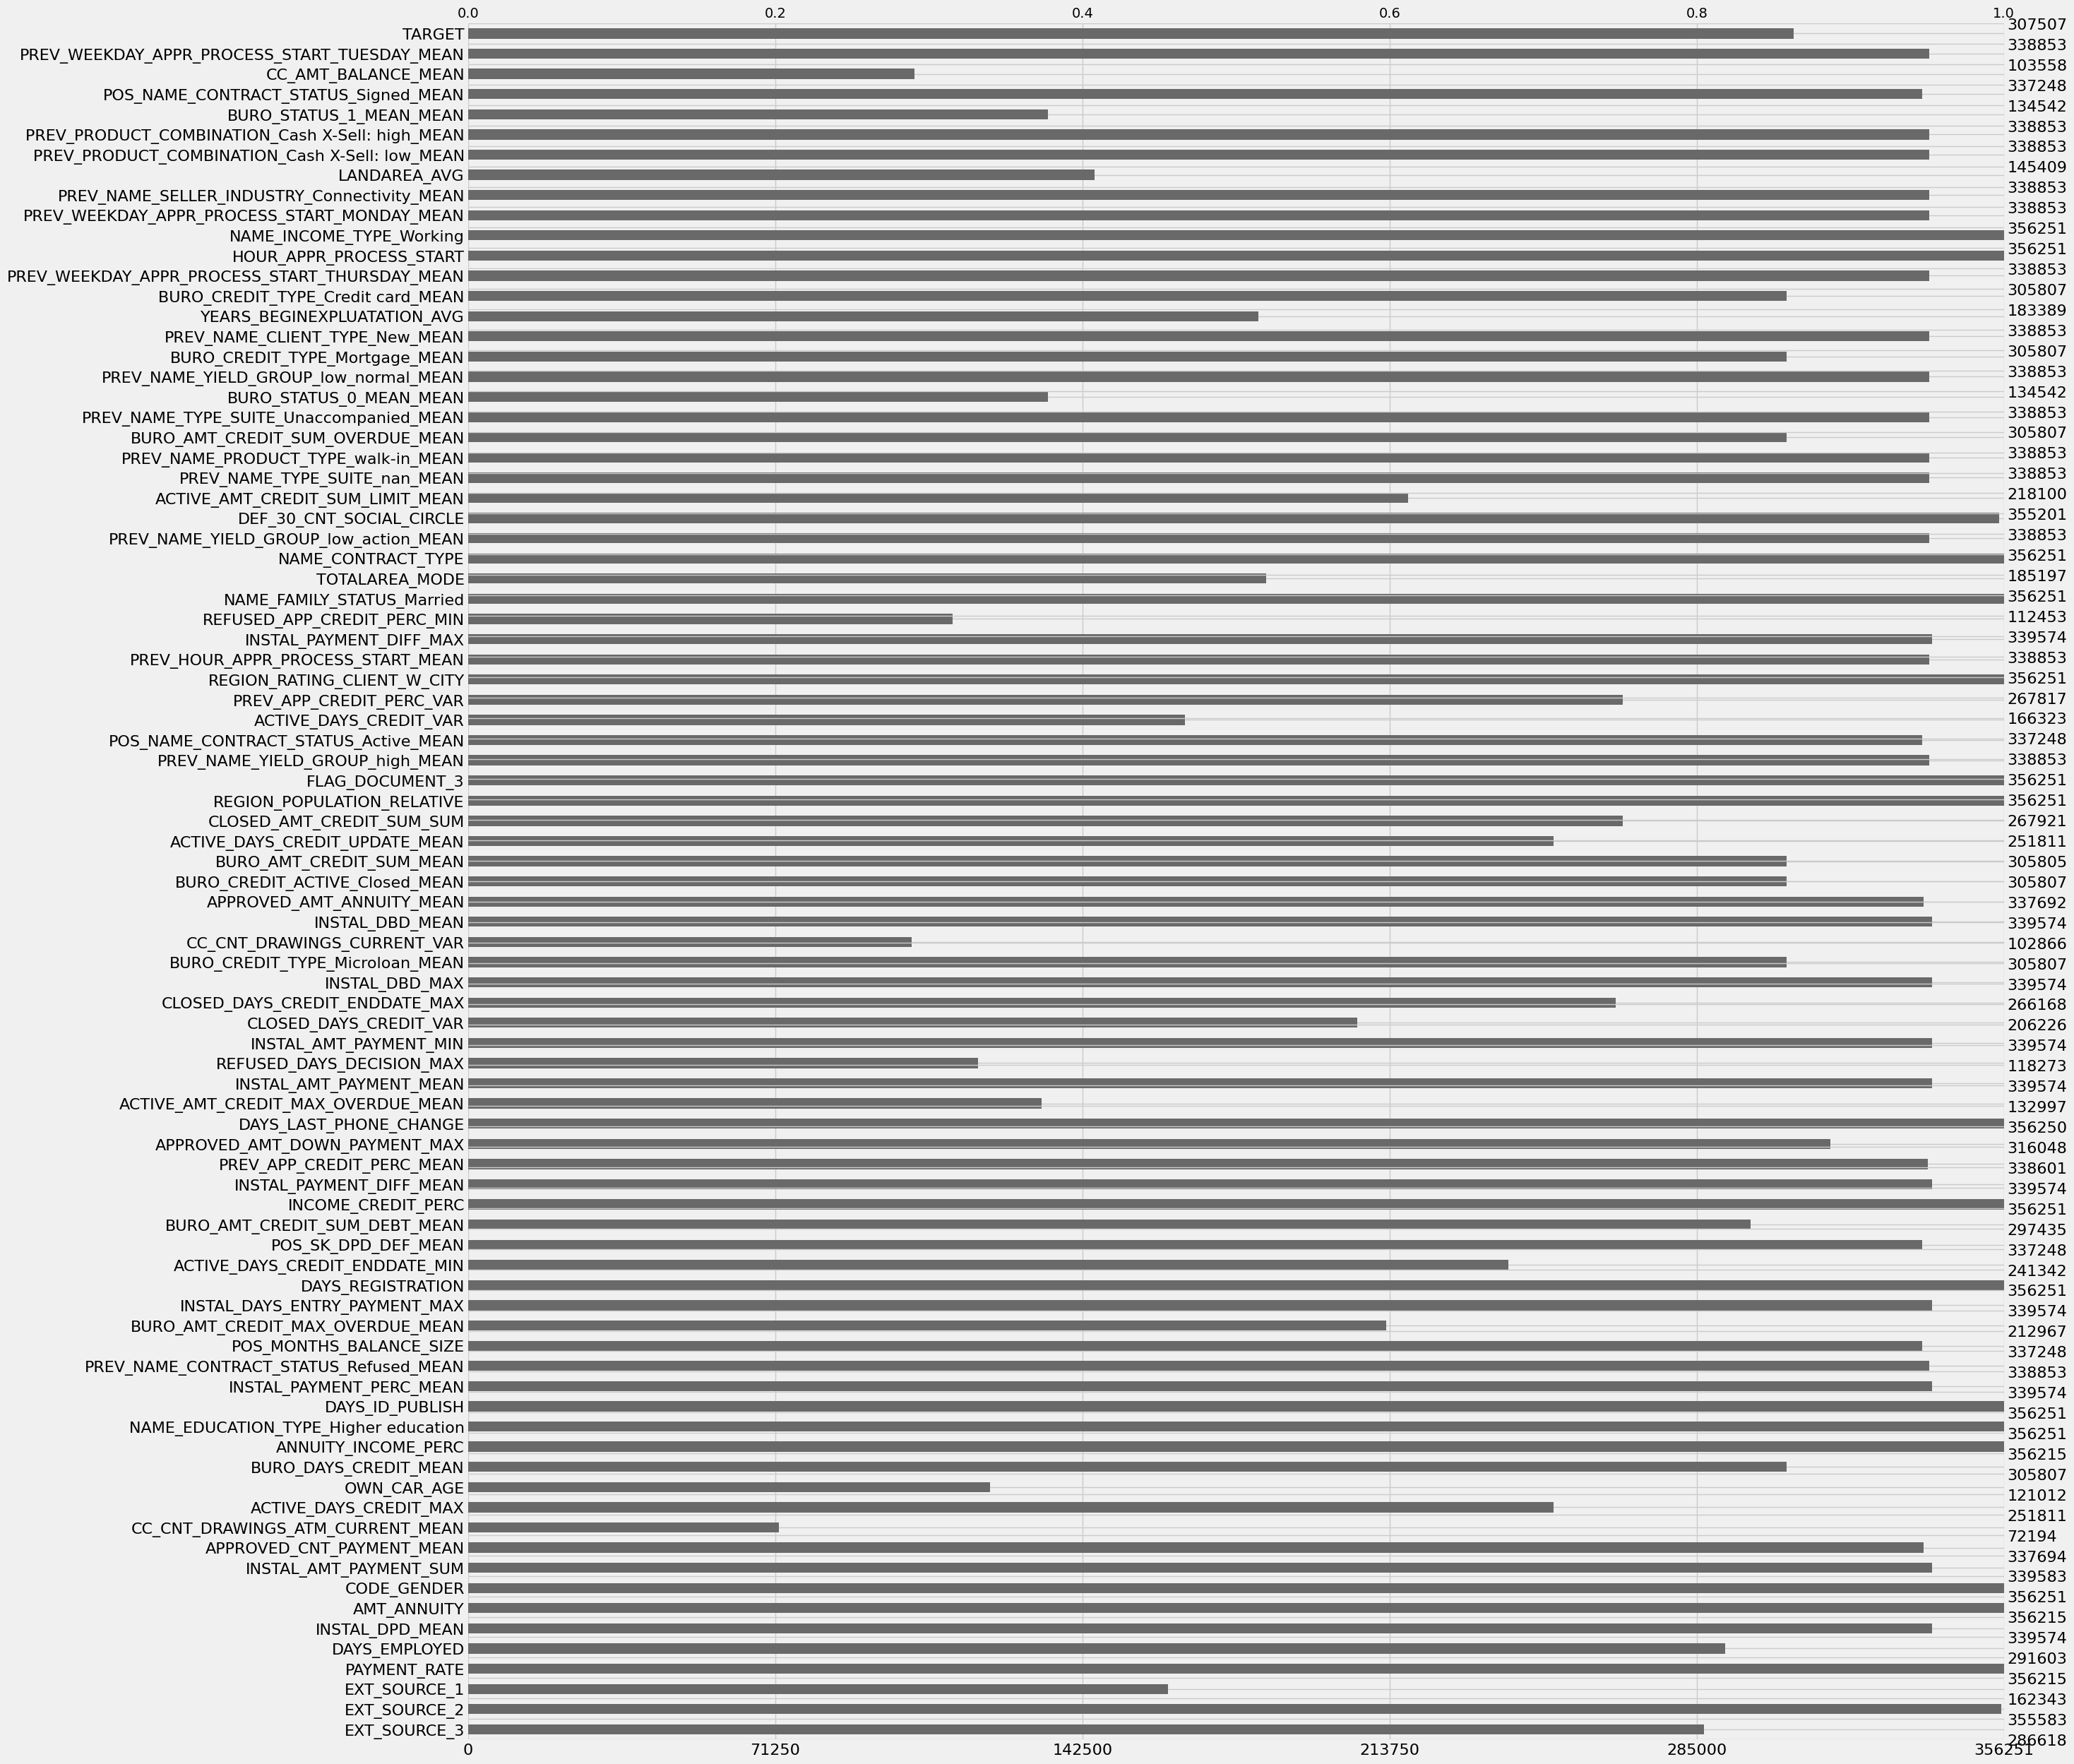

In [116]:
# Dataset filtré (train+test)
ls_features = [f for f in features_keep if f in df.columns]
ls_features.append("TARGET")
df_filtre = df.loc[:, ls_features].copy()
df_filtre.to_csv('df_filtre.csv', index=False)

df_filtre.info()
msno.bar(df_filtre)

#### **2.14. Finalisation “pré-modélisation”**

In [117]:
# On retient: imputation gagnante + pipeline baseline pour la suite (MLflow)
BEST_IMPUTE = best_impute  # récupéré à l'étape 6

final_pipeline = Pipeline(steps=[
    ("cleanup", FunctionTransformer(_cleanup_inf_to_nan, validate=False)),
    ("imputer", SimpleImputer(strategy=("most_frequent" if BEST_IMPUTE=="mode" else BEST_IMPUTE))),
    ("lgbm", LGBMClassifier(
        n_estimators=5000, learning_rate=0.03, num_leaves=48,
        subsample=0.8, colsample_bytree=0.8, max_depth=-1,
        min_child_samples=50, n_jobs=-1, random_state=42, force_col_wise=True
    ))
])

print("Préparation terminée. Pipeline final prêt pour MLflow.")

Préparation terminée. Pipeline final prêt pour MLflow.


### **4. Modélisation** 

#### **4.1. Chargement des données prêtes (imputation = mode) & split**

But : partir du meilleur dataset (imputation par mode) et préparer X / y avec des noms de colonnes sûrs pour LightGBM.

In [118]:
DATA_DIR = "."

In [119]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train_mode_imputed.csv"))

In [120]:
assert "TARGET" in train_df.columns, "La colonne TARGET est manquante."
y = train_df["TARGET"].astype(int).values
X = train_df.drop(columns=["TARGET"]).copy()

In [121]:
# Nettoyage des inf/NaN
X = _cleanup_inf_to_nan(X)

In [122]:
# >>> IMPORTANT : sécuriser les noms de colonnes (LightGBM)
X, name_map = sanitize_feature_names(X)

In [123]:
# Split de travail (tu peux ajuster le random_state)
X_train, X_test, y_train, y_test = train_test_split(
    X.select_dtypes(include=[np.number, "bool"]),  # arbres/linéaires ok
    y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape, np.mean(y_train), np.mean(y_test))

(246005, 83) (61502, 83) 0.08073006646206378 0.08072908198107379


Note : on n’applique pas de StandardScaler aux modèles arbres (LightGBM/RandomForest) ; on le mettra seulement pour la régression logistique (dans un pipeline spécifique).

#### **4.2. MLflow — initialisation et fonction générique de log**

But : tracer chaque run, optimiser un seuil métier sur train, évaluer sur test, et logger toutes les métriques.

In [124]:
mlflow.set_tracking_uri(uri="http://127.0.0.1:5000")

In [125]:
mlflow.set_registry_uri("file:./mlruns")

In [ ]:
mlflow.set_experiment("HomeCredit — Modelisation")

In [ ]:
# Fonctions d'évaluation + logging MLflow
def evaluate_on_test(model, X_tr, y_tr, X_te, y_te,
                     tp_coeff=1.0, fp_coeff=-1.0, fn_coeff=-10.0):
    """Fit, seuil optimal sur train, éval sur test (AUC, AP, metrics + gain métier)."""
    model.fit(X_tr, y_tr)
    proba_tr = model.predict_proba(X_tr)[:, 1]
    best_thr, best_gain_tr = best_threshold_for_business(
        y_tr, proba_tr, tp_coeff, fp_coeff, fn_coeff
    )

    proba_te = model.predict_proba(X_te)[:, 1]
    y_pred_te = (proba_te >= best_thr).astype(int)

    metrics = {
        "rocauc": float(roc_auc_score(y_te, proba_te)),
        "average_precision": float(average_precision_score(y_te, proba_te)),
        "accuracy": float(accuracy_score(y_te, y_pred_te)),
        "precision": float(precision_score(y_te, y_pred_te, zero_division=0)),
        "recall": float(recall_score(y_te, y_pred_te, zero_division=0)),
        "f1": float(f1_score(y_te, y_pred_te, zero_division=0)),
        "business_gain_test": float(compute_business_score(
            y_te, y_pred_te, tp_coeff, fp_coeff, fn_coeff
        )),
        "best_threshold_train": float(best_thr),
        "business_gain_train_at_best_thr": float(best_gain_tr),
    }
    return metrics, model

def _mlflow_safe_metrics(metrics: dict) -> dict:
    safe = {}
    for k, v in metrics.items():
        k2 = re.sub(r"[^A-Za-z0-9_\-./ ]", "_", str(k))  # remplace chars interdits
        safe[k2] = float(v)
    return safe

def log_run_mlflow(model, model_name, X_tr, y_tr, X_te, y_te, params=None, tags=None):
    with mlflow.start_run(run_name=model_name):
        if params: mlflow.log_params(params)
        if tags:
            for k, v in tags.items():
                mlflow.set_tag(k, v)

        metrics, fitted = evaluate_on_test(model, X_tr, y_tr, X_te, y_te)

        # Log metrics
        mlflow.log_metrics(_mlflow_safe_metrics(metrics))

        # Signature & modèle
        signature = infer_signature(X_tr, fitted.predict_proba(X_tr))
        mlflow.sklearn.log_model(fitted, artifact_path="model", signature=signature)

        return metrics, fitted


#### **4.3. Baselines comparatives (Dummy, Logistic, LGBM)**

But : établir une baseline robuste avec ton seuil métier.
On crée 3 pipelines :
- Dummy (référence)
- LogisticRegression (+ imputation + StandardScaler)
- LightGBM (sans scaler)

In [ ]:
# Définition des modèles
dummy_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", DummyClassifier(strategy="most_frequent", random_state=42))
])

logreg_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("scaler", StandardScaler(with_mean=True)),
    ("model", LogisticRegression(max_iter=3000, solver="lbfgs", n_jobs=-1, class_weight="balanced"))
])

lgbm_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("model", LGBMClassifier(
        n_estimators=3000, learning_rate=0.03, num_leaves=48,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1, force_col_wise=True
    ))
])


In [ ]:
# Lancer et logger les baselines
results_baseline = {}

for name, model in [
    ("Dummy", dummy_pipe),
    ("LogisticRegression", logreg_pipe),
    ("LightGBM", lgbm_pipe),
]:
    print(f"▶ {name}")
    metrics, fitted = log_run_mlflow(
        model, f"Baseline — {name}",
        X_train, y_train, X_test, y_test,
        params=None, tags={"phase": "baseline", "imputation": "mode"}
    )
    results_baseline[name] = metrics

pd.DataFrame(results_baseline).T


▶ Dummy


2025/10/24 14:10:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/24 14:12:29 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\marga\AppData\Local\Temp\tmpfzf437nx\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.4.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


🏃 View run Baseline — Dummy at: http://127.0.0.1:5000/#/experiments/903589385276377479/runs/19fa776ee8d645e787e6f51065c23e9e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/903589385276377479
▶ LogisticRegression


2025/10/24 14:13:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Baseline — LogisticRegression at: http://127.0.0.1:5000/#/experiments/903589385276377479/runs/538daeb84d0849f8bcee8781217aedd0
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/903589385276377479
▶ LightGBM
[LightGBM] [Info] Number of positive: 19860, number of negative: 226145
[LightGBM] [Info] Total Bins 15924
[LightGBM] [Info] Number of data points in the train set: 246005, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080730 -> initscore=-2.432469
[LightGBM] [Info] Start training from score -2.432469


2025/10/24 14:14:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


🏃 View run Baseline — LightGBM at: http://127.0.0.1:5000/#/experiments/903589385276377479/runs/c94daf0d4bd94951a618c55648014b80
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/903589385276377479


,rocauc,average_precision,accuracy,precision,recall,f1,business_gain_test,best_threshold_train,business_gain_train_at_best_thr
Dummy,0.500000,0.080729,0.080729,0.080729,1.000000,0.149397,-51572.0,0.000000,-206285.0
LogisticRegression,0.757758,0.229458,0.696677,0.166748,0.689829,0.268575,-29090.0,0.500893,-116672.0
LightGBM,0.781284,0.276195,0.862167,0.274525,0.430614,0.335294,-31782.0,0.148427,-3697.0


#### **4.4. Variante déséquilibre : SMOTE + LGBM**

But : vérifier ta conclusion précédente (SMOTE ≠ nécessaire). On journalise quand même.

In [ ]:
# Pipeline SMOTE + LGBM
smote_lgbm = ImbPipeline(steps=[
    ("cleanup", FunctionTransformer(_cleanup_inf_to_nan, validate=False)),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("smote", SMOTE(sampling_strategy=0.3, k_neighbors=5, random_state=42)),
    ("model", LGBMClassifier(
        n_estimators=3000, learning_rate=0.03, num_leaves=48,
        subsample=0.8, colsample_bytree=0.8, random_state=42,
        n_jobs=-1, force_col_wise=True
    ))
])

metrics_smote, fitted_smote = log_run_mlflow(
    smote_lgbm, "SMOTE + LightGBM",
    X_train, y_train, X_test, y_test,
    tags={"phase": "baseline+smote"}
)
metrics_smote


[LightGBM] [Info] Number of positive: 67843, number of negative: 226145
[LightGBM] [Info] Total Bins 21069
[LightGBM] [Info] Number of data points in the train set: 293988, number of used features: 83
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230768 -> initscore=-1.203980
[LightGBM] [Info] Start training from score -1.203980


2025/10/24 14:18:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/10/24 14:20:15 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\marga\AppData\Local\Temp\tmpwmd04r1b\model\model.pkl, flavor: sklearn). Fall back to return ['scikit-learn==1.4.2', 'cloudpickle==3.1.1']. Set logging level to DEBUG to see the full traceback. 


🏃 View run SMOTE + LightGBM at: http://127.0.0.1:5000/#/experiments/903589385276377479/runs/bdeffd0896404241bb7ec6b787fbb541
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/903589385276377479


{'rocauc': 0.7794583450693583,
 'average_precision': 0.2707352963080449,
 'accuracy': 0.8659555786803681,
 'precision': 0.2789537548874208,
 'recall': 0.41671701913393755,
 'f1': 0.3341947989016314,
 'business_gain_test': -32239.0,
 'best_threshold_train': 0.16143189934651464,
 'business_gain_train_at_best_thr': -6763.0}

| Modèle              |    AUC   |    AP    | Gain test | Commentaire                                 |
| :------------------ | :------: | :------: | :-------: | :------------------------------------------ |
| Dummy               |   0.50   |   0.08   |   –51 k   | baseline neutre                             |
| Logistic Regression |   0.76   |   0.23   |   –29 k   | bon mais limité sur non-linéarités          |
| LightGBM            | **0.78** | **0.28** | **–31 k** | meilleur modèle global                      |
| LightGBM + SMOTE    |   0.78   |   0.27   |   –32 k   | pas d’amélioration, même légère dégradation |


Cela confirme que le LGBM “simple” sans SMOTE reste le meilleur modèle, stable et performant. Le seuil métier optimal ≈ 0.15 fonctionne bien : il équilibre précision/recall sans sacrifier trop de gain.

#### **4.5. RandomSearchCV ciblé (LogReg & LGBM)**

But : une optimisation simple des hyperparamètres avec MLflow, suivie de l’éval test + log.

In [ ]:
# Échantillon de tuning (stratifié)
from sklearn.model_selection import train_test_split

# Taille du sous-ensemble pour le tuning (ajuste si besoin)
TUNE_SIZE = 80_000

X_tune, _, y_tune, _ = train_test_split(
    X_train, y_train,
    train_size=min(TUNE_SIZE, len(X_train)),
    stratify=y_train,
    random_state=42
)

X_tune.shape, y_tune.mean()

In [ ]:
param_distributions_lgbm = {
    "model__num_leaves": randint(24, 72),           # 24..71
    "model__min_child_samples": randint(20, 120),   # 20..119
    "model__learning_rate": uniform(0.015, 0.04),   # ~0.015..0.055
    "model__subsample": uniform(0.6, 0.4),          # 0.6..1.0
    "model__colsample_bytree": uniform(0.6, 0.4),   # 0.6..1.0
    "model__n_estimators": randint(1200, 2200),     # 1200..2199 (compromis vitesse/qualité)
    # fixes utiles
    "model__random_state": [42],
    "model__force_col_wise": [True],
}

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rs_lgbm = RandomizedSearchCV(
    estimator=lgbm_pipe,
    param_distributions=param_distributions_lgbm,
    n_iter=25,              # ← ajuste (10=très rapide, 25=raisonnable)
    cv=cv3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

with mlflow.start_run(run_name="RandomSearch — LightGBM"):
    rs_lgbm.fit(X_tune, y_tune)

    # Log best params + CV score
    mlflow.log_params(rs_lgbm.best_params_)
    mlflow.log_metric("cv_best_auc", rs_lgbm.best_score_)

    # Évalue sur le vrai test (avec notre fonction déjà définie)
    metrics_lgbm_fast, fitted_lgbm_fast = evaluate_on_test(
        rs_lgbm.best_estimator_, X_train, y_train, X_test, y_test
    )
    mlflow.log_metrics(metrics_lgbm_fast)

    # Log modèle
    signature = infer_signature(X_train, fitted_lgbm_fast.predict_proba(X_train))
    mlflow.sklearn.log_model(fitted_lgbm_fast, "model", signature=signature)

metrics_lgbm_fast

In [ ]:
# Grille réduite pour logreg (rapide)
param_distributions_logreg = {
    "model__C": uniform(0.03, 5.0),        # ~0.03..5.03
    "model__class_weight": ["balanced", None],
    "model__max_iter": [2000],
    "model__solver": ["lbfgs"],            # robuste
    "model__penalty": ["l2"],
}

rs_logreg = RandomizedSearchCV(
    estimator=logreg_pipe,
    param_distributions=param_distributions_logreg,
    n_iter=20,
    cv=cv3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

with mlflow.start_run(run_name="RandomSearch — LogisticRegression"):
    rs_logreg.fit(X_tune, y_tune)

    mlflow.log_params(rs_logreg.best_params_)
    mlflow.log_metric("cv_best_auc", rs_logreg.best_score_)

    metrics_logreg_fast, fitted_logreg_fast = evaluate_on_test(
        rs_logreg.best_estimator_, X_train, y_train, X_test, y_test
    )
    mlflow.log_metrics(metrics_logreg_fast)

    signature = infer_signature(X_train, fitted_logreg_fast.predict_proba(X_train))
    mlflow.sklearn.log_model(fitted_logreg_fast, "model", signature=signature)

pd.DataFrame({
    "LightGBM_fast": metrics_lgbm_fast,
    "LogReg_fast": metrics_logreg_fast
}).T

In [ ]:
# Choisis le meilleur des deux (souvent LightGBM chez toi)
final_lgbm = rs_lgbm.best_estimator_

with mlflow.start_run(run_name="Final — LightGBM (best from RS)"):
    # fit sur tout le train
    final_lgbm.fit(X_train, y_train)

    # évalue une dernière fois
    metrics_final, fitted_final = evaluate_on_test(final_lgbm, X_train, y_train, X_test, y_test)
    mlflow.log_metrics(metrics_final)

    # log final model
    signature = infer_signature(X_train, fitted_final.predict_proba(X_train))
    mlflow.sklearn.log_model(fitted_final, "model", signature=signature)

metrics_final


#### **4.6. Sauvegarde pipeline final (joblib + MLflow)**

But : sérialiser un pipeline de prédiction prêt pour l’API / le batch scoring.

In [ ]:
# Sauvegarde joblib + MLflow

# Fit final sur tout le train
final_lgbm.fit(X_train, y_train)

# Évalue et log dans MLflow
with mlflow.start_run(run_name=f"FinalModel-LightGBM-{datetime.now().strftime('%Y%m%d_%H%M%S')}"):
    metrics_final, fitted_final = evaluate_on_test(final_lgbm, X_train, y_train, X_test, y_test)
    mlflow.log_metrics(metrics_final)

    # Seuil optimal sur tout le train (on utilise la même logique que evaluate_on_test)
    y_proba_train = fitted_final.predict_proba(X_train)[:, 1]
    thr_grid = np.linspace(0, 1, 201)
    best_thr = None
    best_gain = -np.inf
    for thr in thr_grid:
        y_pred_bin = (y_proba_train >= thr).astype(int)
        gain = compute_business_score(y_train, y_pred_bin)
        if gain > best_gain:
            best_gain = gain
            best_thr = thr

    mlflow.log_metric("final_best_threshold_train", float(best_thr))
    mlflow.log_metric("final_business_gain_train@best_thr", float(best_gain))

    # Signature + log modèle
    signature = infer_signature(X_train, fitted_final.predict_proba(X_train))
    mlflow.sklearn.log_model(fitted_final, "model", signature=signature)


In [ ]:
os.makedirs("artifacts", exist_ok=True)
joblib_path = os.path.join("artifacts", "pipeline_lightgbm_final.joblib")
joblib.dump(final_lgbm, joblib_path)
print(f"Modèle sauvegardé: {joblib_path}")

#### **4.7. Explicabilité SHAP (sur le meilleur LGBM)**

But : voir les features principales et expliquer quelques prédictions.

In [ ]:
# SHAP summary & force plot
# Récupérer le LGBM "nu" (dans le pipeline final)
lgbm_est = final_lgbm.named_steps["model"]

# SHAP s'attend à des numpy/pandas. On prend un échantillon si besoin.
X_sample = X_test.copy()
explainer = shap.TreeExplainer(lgbm_est)
shap_values = explainer(X_sample)

# Top 20
shap.summary_plot(shap_values, X_sample, feature_names=X_sample.columns.tolist(),
                  plot_type="violin", max_display=20)


In [ ]:
# Explication d’un client (au hasard)
import random
idx = random.randint(0, len(X_sample)-1)
shap.force_plot(explainer.expected_value, shap_values.values[idx, :], X_sample.iloc[idx, :])


#### **4.8. Data Drift (Evidently)**

But : comparer train vs test (features uniquement).

In [ ]:
DATA_DIR = "Data"
app_train = pd.read_csv(f"{DATA_DIR}/application_train.csv")
app_test  = pd.read_csv(f"{DATA_DIR}/application_test.csv")


In [ ]:
# Séparer la cible et ne garder que les features
ref = app_train.drop(columns=[c for c in ["TARGET"] if c in app_train.columns]).copy()
cur = app_test.copy()

In [ ]:
# Harmoniser les schémas (mêmes colonnes & types)
# Ajouter les colonnes manquantes côté test
for col in ref.columns:
    if col not in cur.columns:
        cur[col] = np.nan
# Supprimer côté test ce qui n’existe pas côté train
extra_cols = [c for c in cur.columns if c not in ref.columns]
cur = cur.drop(columns=extra_cols)

# Réordonner pour correspondre exactement au train
cur = cur[ref.columns]

# Forcer des types compatibles (option simple : laisser pandas inférer + laisser Evidently gérer)
for c in ref.columns:
    if ref[c].dtype == bool and c in cur.columns:
        cur[c] = cur[c].astype("boolean")  # dtype nullable compatible

In [ ]:
# Construire le rapport Evidently (preset complet de drift)
report = Report(metrics=[
    DataDriftPreset(),          # vue d'ensemble (KS test, PSI, etc.)
    DatasetDriftMetric(),       # métrique globale "dataset drift"
    DataDriftTable(),           # tableau des features avec statut drift / pas drift
])

report.run(reference_data=ref, current_data=cur)

In [ ]:
# Afficher inline (si ton notebook le supporte) et sauvegarder en HTML
report.show(mode="inline")
report.save_html("data_drift_report.html")
print("✅ Rapport Evidently généré : data_drift_report.html")